# 33회 ADP 복원 

# 기계학습 (60점)

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib
import warnings

warnings.filterwarnings('ignore')

## 데이터 설명
- 데이터 출처 : https://archive.ics.uci.edu/ml/datasets/HCV+data 후처리
- 데이터 링크 : ./data/p1.csv
- 데이터 설명 : 혈액수치 데이터, 간염 정도에 따른

Category (종속변수) 
- 0: 정상
- 1,2,3 (간염 정도, 심각성 : 3>2>1, 3은 간경화)


In [2]:
dt1 = pd.read_csv("https://raw.githubusercontent.com/Datamanim/datarepo/refs/heads/master/adp/33/data/p1.csv")
print(dt1.info())
display(dt1.head(3))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 608 entries, 0 to 607
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Category  608 non-null    object 
 1   Age       608 non-null    int64  
 2   Sex       608 non-null    object 
 3   ALB       607 non-null    float64
 4   ALP       590 non-null    float64
 5   ALT       607 non-null    float64
 6   AST       608 non-null    float64
 7   BIL       608 non-null    float64
 8   CHE       608 non-null    float64
 9   CHOL      598 non-null    float64
 10  CREA      608 non-null    float64
 11  GGT       608 non-null    float64
 12  PROT      607 non-null    float64
dtypes: float64(10), int64(1), object(2)
memory usage: 61.9+ KB
None


,Category,Age,Sex,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT
0,0=B,32,m,38.5,52.5,7.7,22.1,7.5,6.93,3.23,106.0,12.1,69.0
1,0=B,32,m,38.5,70.3,18.0,24.7,3.9,11.17,4.80,74.0,15.6,76.5
2,0=B,32,m,46.9,74.7,36.2,52.6,6.1,8.84,5.20,86.0,33.2,79.3


In [3]:
dt1.isna().sum()

Category     0
Age          0
Sex          0
ALB          1
ALP         18
ALT          1
AST          0
BIL          0
CHE          0
CHOL        10
CREA         0
GGT          0
PROT         1
dtype: int64

5개의 변수에서 결측치가 발견되었다.(ALB, ALP:18, ALT, CHOL:10, PROT)

In [4]:
# 기초통계량 확인
display(dt1.describe(include='object').T)
display(dt1.describe().T)

,count,unique,top,freq
Category,608,4,0=B,533
Sex,608,2,m,371


,count,mean,std,min,25%,50%,75%,max
Age,608.0,47.291118,9.992705,19.00,39.00,47.00,54.000,77.00
ALB,607.0,41.818781,5.406717,20.00,39.00,42.00,45.250,82.20
ALP,590.0,67.821017,25.274423,11.30,52.50,66.00,79.525,416.60
ALT,607.0,27.601318,21.227539,0.90,16.40,23.00,32.750,258.00
AST,608.0,34.369408,32.622442,12.00,21.60,25.85,32.800,324.00
BIL,608.0,11.474013,19.770558,1.80,5.30,7.30,11.300,254.00
CHE,608.0,8.204885,2.168400,1.42,6.95,8.27,9.585,16.41
CHOL,598.0,5.378829,1.119394,1.43,4.62,5.30,6.075,9.67
CREA,608.0,81.513158,49.720652,8.00,68.00,77.00,88.000,1079.10
GGT,608.0,38.243914,51.953220,4.50,15.70,23.25,39.200,650.90


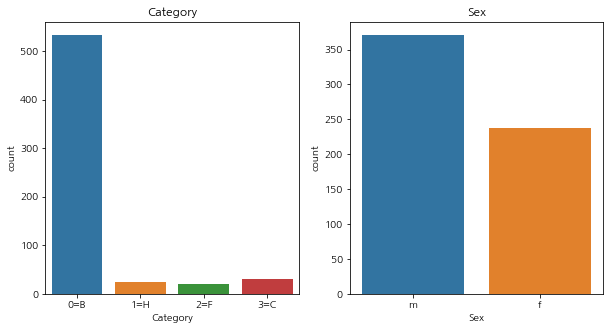

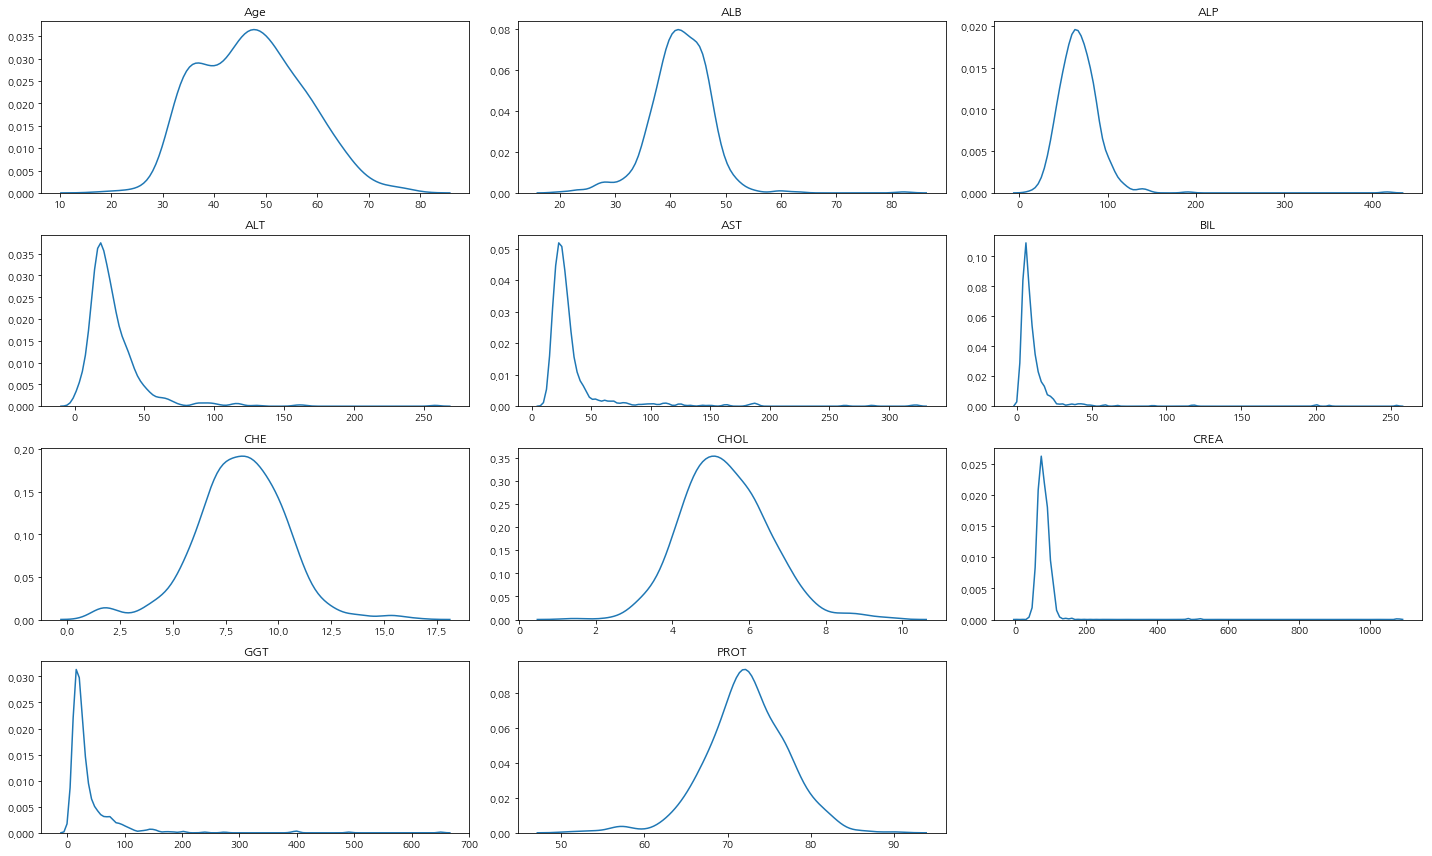

In [5]:
#분포 확인
c_cols = dt1.select_dtypes('O').columns
n_cols = dt1.select_dtypes('number').columns

#count_plot
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

for i, col in enumerate(c_cols):
    sns.countplot(dt1[col], ax=ax[i])
    ax[i].set_title(col)
plt.show()
#kde plot
fig, ax = plt.subplots(4, 3, figsize=(20, 12))

for i, col in enumerate(n_cols):
    x = i // 3
    y = i % 3
    sns.kdeplot(data=dt1[col], ax=ax[x, y], legend=False)
    ax[x, y].set_title(col)
ax[3, 2].remove()
plt.tight_layout()
plt.show()

통계량과 분포 그래프(카테고리형: cout plot, 연속형: kde plot)를 통해 다음과 같은 사실을 알 수 있다.  
- 간염이 아닌 사람의 비율이 나머지 레이블보다 압도적으로 높다.(불균형 데이터)
- 남성의 비율이 여성보다 높다. 
- CHE, PROT를 제외한 모든 설명변수가 오른쪽 꼬리가 긴 양의 왜도를 가짐

## 1-1  결측치 처리 방안 2개 제시하고, 처리 전후 비교 및 더 나은 방안 선택하여 전처리 완료

| 처리 방법      | 설명                            | 장점                          | 단점                                | 적합한 상황                       |
| ---------- | ----------------------------- | --------------------------- | --------------------------------- | ---------------------------- |
| **대푯값 대치** | 평균, 중앙값, 최빈값 등으로 결측값을 대체      | - 빠르고 간단<br>- 대부분 모델에서 작동   | - 분포 왜곡<br>- 분산 감소<br>- 예측력 저하 가능 | - 결측 비율이 낮고<br>- 데이터가 단순할 때  |
| **결측값 제거** | 결측치 포함된 행/열을 삭제               | - 왜곡 없음<br>- 처리 간단          | - 데이터 손실 위험<br>- 표본 편향 가능성        | - 결측치가 적고 무작위 발생(MCAR)인 경우   |
| **모델링 대치** | KNN, 회귀, 다중대치 등으로 결측값을 예측해 대체 | - 변수 간 관계 반영<br>- 정확도 보존 가능 | - 구현 복잡<br>- 과적합 가능<br>- 계산 비용 큼  | - 결측이 많고<br>- 변수 간 관계가 뚜렷할 때 |


여기서는 대푯값인 중앙값 대치(Category, Sex 그룹), 그리고 결측값 제거 두 방안으로 결측치 처리 후 비교한다.

In [6]:
# 중앙값 대치
null_cols = dt1.columns[dt1.isna().sum() > 0].values
dt1_1 = dt1.copy()
for col in null_cols:
    g_median = dt1_1.groupby(['Category', 'Sex'])[col].transform('median') #각 행에 맞게 중앙값 반환
    dt1_1[col] = dt1_1[col].fillna(g_median)
dt1_1.isna().sum()

Category    0
Age         0
Sex         0
ALB         0
ALP         0
ALT         0
AST         0
BIL         0
CHE         0
CHOL        0
CREA        0
GGT         0
PROT        0
dtype: int64

In [7]:
# 결측값 제거
dt1.isna().mean()

Category    0.000000
Age         0.000000
Sex         0.000000
ALB         0.001645
ALP         0.029605
ALT         0.001645
AST         0.000000
BIL         0.000000
CHE         0.000000
CHOL        0.016447
CREA        0.000000
GGT         0.000000
PROT        0.001645
dtype: float64

결측값이 1~ 3% 미만이다. 전체 데이터 비율에서 큰 비중을 차지하지 않으므로 삭제한다. 

In [8]:
dt1_2 = dt1.copy()

dt1_2 = dt1_2.dropna()

In [9]:
# describe 확인
print("원본:결측치 포함")
display(dt1.describe()[null_cols].T)
print("종속변수, 성별 그룹 중앙값 대치")
display(dt1_1.describe()[null_cols].T)
print("결측치 삭제")
display(dt1_2.describe()[null_cols].T)

원본:결측치 포함


,count,mean,std,min,25%,50%,75%,max
ALB,607.0,41.818781,5.406717,20.00,39.00,42.0,45.250,82.20
ALP,590.0,67.821017,25.274423,11.30,52.50,66.0,79.525,416.60
ALT,607.0,27.601318,21.227539,0.90,16.40,23.0,32.750,258.00
CHOL,598.0,5.378829,1.119394,1.43,4.62,5.3,6.075,9.67
PROT,607.0,72.253213,4.932252,51.00,69.45,72.2,75.400,90.00


종속변수, 성별 그룹 중앙값 대치


,count,mean,std,min,25%,50%,75%,max
ALB,608.0,41.800987,5.420049,20.00,39.000,42.000,45.225,82.20
ALP,608.0,67.358635,25.256428,11.30,52.175,65.650,79.300,416.60
ALT,608.0,27.591118,21.211537,0.90,16.400,22.950,32.675,258.00
CHOL,608.0,5.372763,1.114565,1.43,4.620,5.305,6.060,9.67
PROT,608.0,72.248026,4.929847,51.00,69.400,72.200,75.400,90.00


결측치 삭제


,count,mean,std,min,25%,50%,75%,max
ALB,582.0,41.831443,5.369272,23.00,39.000,41.95,45.1750,82.20
ALP,582.0,67.651890,25.148941,11.30,52.500,66.00,79.3000,416.60
ALT,582.0,25.666838,14.920906,0.90,16.325,22.50,31.7500,118.10
CHOL,582.0,5.402646,1.114920,1.43,4.630,5.31,6.0875,9.67
PROT,582.0,72.106357,4.857867,51.00,69.300,72.10,75.2000,86.50


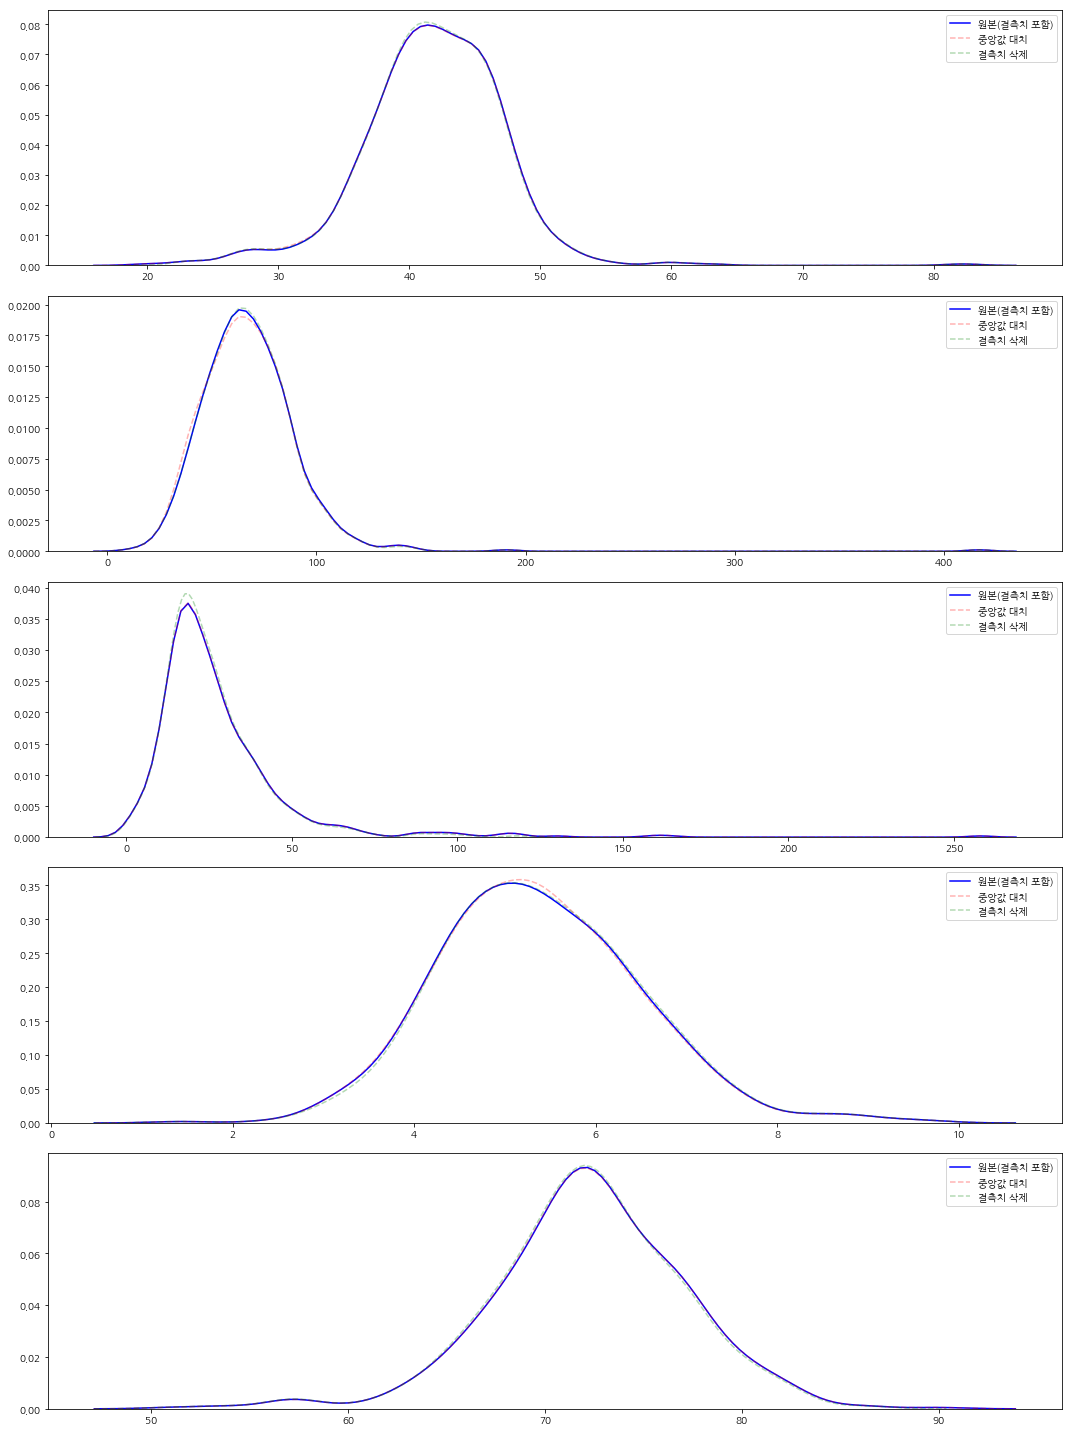

In [31]:
fig, ax = plt.subplots(5, 1, figsize=(15, 20))

for i, col in enumerate(null_cols):
    sns.kdeplot(data=dt1[col], legend=True, ax=ax[i], color='b', label='원본(결측치 포함)', alpha=1)
    sns.kdeplot(data=dt1_1[col], legend=True, ax=ax[i], color='r', label='중앙값 대치', alpha=0.3, ls='--')
    sns.kdeplot(data=dt1_2[col], legend=True, ax=ax[i], color='g', label='결측치 삭제', alpha=0.3, ls='--')
plt.tight_layout()
plt.show()

데이터의 분포를 비교하였을 때, 대동소이하다.   
데이터 활용도를 고려했을 시 중앙값 대치를 선택한다. 

## 1-2 이상치를 확인하고 처리 여부 판단 후 작업

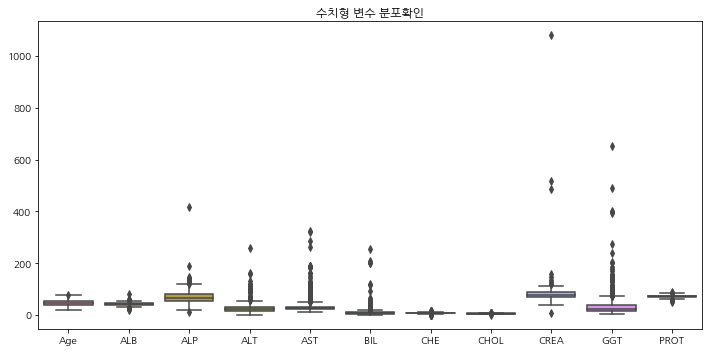

In [622]:
# 이상치 확인을 위한 boxplot
plt.figure(figsize=(10, 5))
sns.boxplot(data=dt1[n_cols])
plt.title('수치형 변수 분포확인')
plt.tight_layout()
plt.show()

Age 이상치 수: 1 (0.16 %)
ALB 이상치 수: 22 (3.62 %)
ALP 이상치 수: 10 (1.64 %)
ALT 이상치 수: 34 (5.59 %)
AST 이상치 수: 61 (10.03 %)
BIL 이상치 수: 46 (7.57 %)
CHE 이상치 수: 23 (3.78 %)
CHOL 이상치 수: 12 (1.97 %)
CREA 이상치 수: 10 (1.64 %)
GGT 이상치 수: 68 (11.18 %)
PROT 이상치 수: 14 (2.30 %)


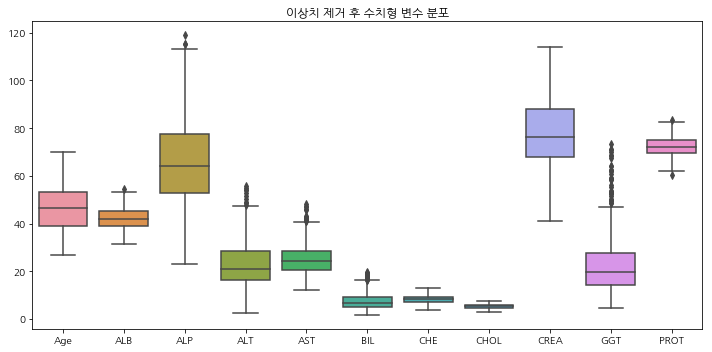

In [623]:
#일단 iqr 기준으로 이상치 개수 확인
dt1 = dt1_1

ds = dt1.describe().T
q1 = ds['25%']
q3 = ds['75%']
iqr = q3 - q1
down = q1 -1.5*iqr
up = q3 + 1.5*iqr

new_dt = dt1.copy()
for col in n_cols:
    r_dt = dt1[(dt1[col] > up[col]) | (dt1[col] < down[col])]
    print(f"{col} 이상치 수: {len(r_dt)} ({len(r_dt)/len(dt1)*100:.2f} %)")
    new_dt = new_dt[~new_dt.index.isin(r_dt.index)]
    
#이상치 제거 후
plt.figure(figsize=(10, 5))
sns.boxplot(data=new_dt[n_cols])
plt.title('이상치 제거 후 수치형 변수 분포')
plt.tight_layout()
plt.show()

많은 변수에서 outlier로 보이는 point들이 식별된다.  
특히 CREA, GGT 변수의 경우 상당히 높은 값들이 식별되는데, 해당 데이터에 대한 도메인 지식이 없으며,  
이상치처럼 보이는 값들이 실제 모델 학습에서 중요할 수도 있기 때문에 제거하지 않고 학습에 사용한다.

IQR 기준 하한치, 상한치 기준으로 이상치 수를 판별했을 시, 예를 들어 나이의 이상치가 1개 식별(77세)되었으나,  
실제 77세는 존재할 수 있는 수치이기 때문에 수치적 기준만을 적용하여 삭제하기는 적절치 않다.

## 1-3. 위 두 작업 적용 후 EDA 진행 및 종속변수를 기준으로 각 독립변수의 차이가 있는지 확인하라 (시각화포함)

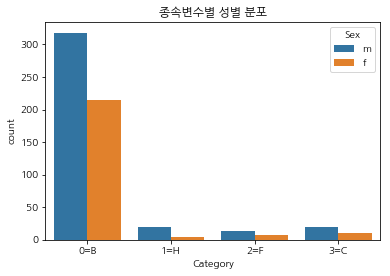

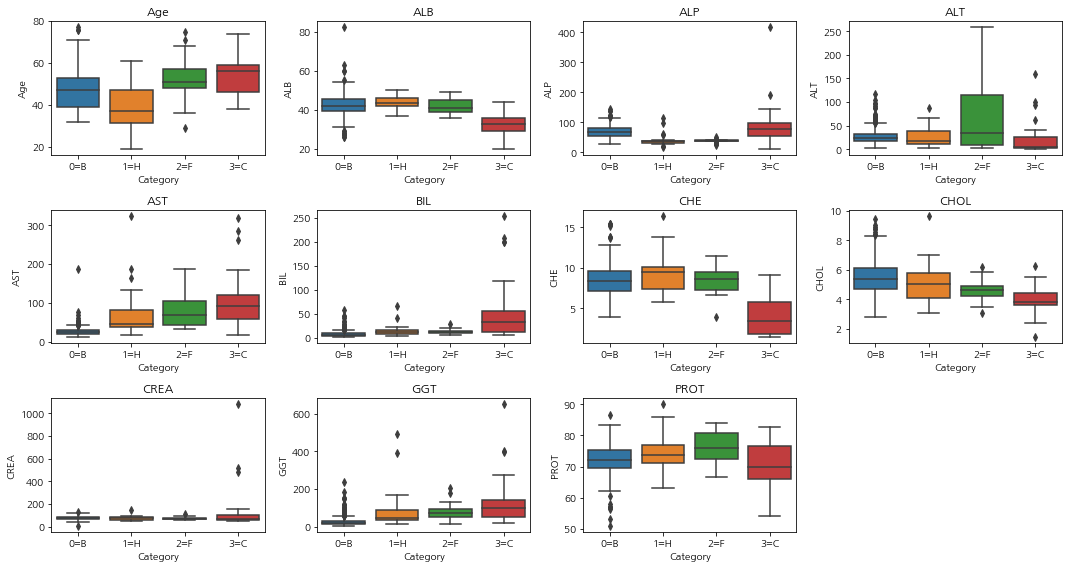

In [624]:
#카테고리형: 성별
sns.countplot(dt1['Category'], hue=dt1['Sex'])
plt.title('종속변수별 성별 분포')
plt.show()

#수치형
fig, ax = plt.subplots(3, 4, figsize=(15, 8))

for i, col in enumerate(n_cols):
    x = i // 4
    y = i % 4
    sns.boxplot(x='Category', y=col, data=dt1, ax=ax[x, y])
    ax[x, y].set_title(col)
ax[2, 3].remove()
plt.tight_layout()
plt.show()

- 성별: 남녀 모두 간염이 아닌 사람이 대부분이며, 간염인 경우 남성은 3 > 1 > 2 순이며, 여성은 3 > 2 > 1 순이다. 
- 나이: 감염자의 경우 고령자일수록 간염 정도가 심각한 경향을 보임
- 중증일수록 AST, BIL, GGT가 높아지는 경향이 있음
- 중증일수록 ALB, CHE, CHOL가 낮아지는 경향이 있음

종속변수(범주형: 4)별 독립변수(연속, 범주형:성별) 차이가 있는지 확인

정규성을 만족한다면 모수 검정, 만족하지 않는다면 모집단에 대한 분산 가정이 없는 비모수 검정을 실시한다.  
따라서, 검정 전 정규성을 확인하기 위해 Shapiro(소규모 데이터이므로) 검정을 실시한다. 

- 다중범주-연속형 변수: one-way anova 분석(정규성 만족),  Kruskal-Wallis H 검정(정규성 비만족) 
- 다중범주-범주: 카이제곱 독립성 검정

모든 검정은 유의확률 5% 하에서 실시한다.

In [625]:
# 정규성, 등분산성 확인
#정규성 가정: H0: 정규성을 만족한다. / H1: 정규성을 만족하지 않는다.
#등분산 가정: H0: 등분산을 만족한다. / H1: 등분산을 만족하지 않는다.
from scipy.stats import shapiro, levene

cl = dt1['Category'].unique() # 종속변수
rs = pd.DataFrame(columns=['name', 'stat(0=B)', 'stat(0=B)', 'stat(1=B)', 'stat(2=B)', '등분산검정', '정규성만족', '등분산성만족'])

for col in n_cols:
    s = [] #샤피로
    g = [] #종속변수 클래스별 데이터셋
    for cc in cl:
        g_t = dt1[dt1['Category'] == cc][col]
        stat, p = shapiro(g_t)
        s.append(round(p, 2))
        g.append(g_t)
        s_ok = ['O' if sum([x >= 0.05 for x in s]) == 4 else 'X']
        l_ok = ['O' if p>= 0.05 else 'X']
    stat, p = levene(g[0], g[1], g[2], g[3])
    rs.loc[len(rs)] = [col]+s+[round(p, 2)]+s_ok+l_ok
display(rs)

,name,stat(0=B),stat(0=B),stat(1=B),stat(2=B),등분산검정,정규성만족,등분산성만족
0,Age,0.0,0.71,0.92,0.34,0.65,X,O
1,ALB,0.0,0.64,0.39,0.83,0.33,X,O
2,ALP,0.0,0.00,0.02,0.00,0.00,X,X
3,ALT,0.0,0.00,0.00,0.00,0.00,X,X
4,AST,0.0,0.00,0.03,0.00,0.00,X,X
5,BIL,0.0,0.00,0.03,0.00,0.00,X,X
6,CHE,0.0,0.07,0.68,0.00,0.14,X,X
7,CHOL,0.0,0.04,0.89,0.12,0.03,X,O
8,CREA,0.0,0.00,0.06,0.00,0.00,X,X
9,GGT,0.0,0.00,0.05,0.00,0.00,X,X


모든 독립변수가 정규성을 만족하지 않는다. 따라서 비모수 검정인 Kruskal-Wallis H 검정을 실시한다.  
범주형 변수인 Sex에 대해서는 교차표 생성 후 카이제곱 독립성 검정을 실시한다.

In [626]:
from scipy.stats import kruskal, chi2_contingency

#H0: 종속변수와 해당 독립변수 간 관계는 연관이 없다.(독립) / H1: 종속변수와 독립변수 간 관계는 통계적으로 연관이 있다.

cl = dt1['Category'].unique() # 종속변수
rs = pd.DataFrame(columns=['name', 'stat', 'p-value', '차이여부'])
# 수치-명목(종속)
for col in n_cols:
    k = [] #크루스칼왈리스
    g = [] #종속변수 클래스별 데이터셋
    for cc in cl:
        g_t = dt1[dt1['Category'] == cc][col]
        g.append(g_t)
    stat, p = kruskal(g[0], g[1], g[2], g[3])    
    d_ok = ['O' if p < 0.05 else 'X'] #o:차이있음
    rs.loc[len(rs)] = [col]+[stat]+[round(p, 2)]+d_ok
    
# 명목(설명)-명목(종속)
cr = pd.crosstab(dt1['Category'], dt1['Sex'])
stat, p, ddof, expected = chi2_contingency(cr)
d_ok = ['O' if p < 0.05 else 'X'] #o:차이있음
rs.loc[len(rs)] = ['Sex']+[stat]+[round(p, 2)]+d_ok
display(rs)

,name,stat,p-value,차이여부
0,Age,29.465045,0.00,O
1,ALB,62.360698,0.00,O
2,ALP,90.552695,0.00,O
3,ALT,21.927342,0.00,O
4,AST,158.142287,0.00,O
5,BIL,93.648308,0.00,O
6,CHE,67.088464,0.00,O
7,CHOL,61.099187,0.00,O
8,CREA,10.241494,0.02,O
9,GGT,106.328307,0.00,O


종속변수의 각 클래스(범주)에 따라 설명변수들의 분포에 차이가 있는지 통계적으로 검정하였다.  
연속형 설명변수 11개에 대해서는 Kruskal–Wallis 검정을, 명목형 변수인 Sex에 대해서는 카이제곱 독립성 검정을 수행하였다.  
유의수준 5% 하에서 Sex를 제외한 모든 설명변수에서 통계적으로 유의한 차이가 나타났으며, 이는 종속변수 클래스에 따라  
해당 변수 값이 달라질 가능성이 있음을 시사한다.

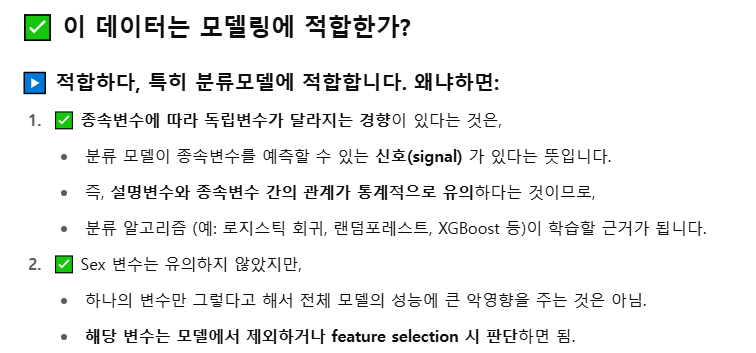

## 1-4 주어진 데이터로부터 주성분분석을 수행해 새로운 설명변수를 도출할 수 있는지를 검토 ∙ 판단한 뒤, 그 결과를 제시하시오

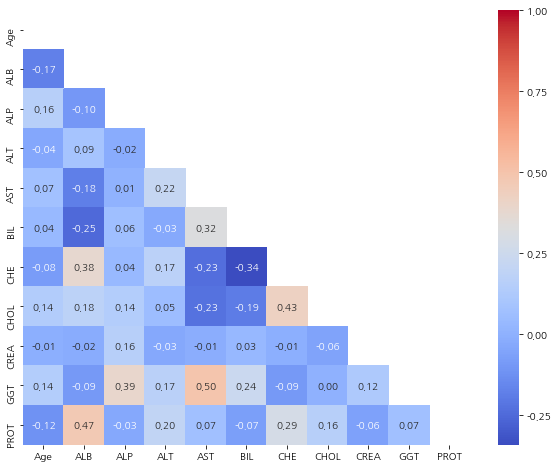

In [627]:
plt.figure(figsize=(10, 8))
corr = dt1.corr()
mask = np.triu(np.ones_like(corr, dtype='bool'))
sns.heatmap(corr, mask=mask, cmap='coolwarm', annot=True, fmt=".2f")
plt.show()

피어슨 상관관계(선형) 분석결과, 설명변수 간 유의한 상관관계가 관찰되지 않는다.   
다만, ALB-PROT(0.47), CHE-CHOL(0.43), CHE-ALB(0.38), GGT-AST(0.5), PROT-ALB(0.47) 등 약~중간 상관을 가진 변수 쌍은 관찰된다.  
PCA는 강한 다중공선성, 고차원이 아닌 경우 선택적이다. 다중공선성이 관찰되지 않지만 수치 상으로 정확하게 확인하기 위해  
VIF를 확인한다. 

In [628]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()
vif['name'] = n_cols
vif['vif'] = [variance_inflation_factor(dt1[n_cols].values, i) for i in range(len(n_cols))]

display(vif)

,name,vif
0,Age,22.501130
1,ALB,89.696338
2,ALP,10.398941
3,ALT,3.069098
4,AST,3.498735
5,BIL,1.660373
6,CHE,23.789948
7,CHOL,32.368961
8,CREA,3.783399
9,GGT,2.577404


6개의 변수에서 굉장히 높은(10이상) vif 수치가 나왔다.  
앞서 피어슨 상관계수는 높은 수치가 없었지만, vif에서 높은 수치가 나왔다는 것은 "다중조합형 공선성"으로 볼 수 있다.  
따라서 PCA를 통해 다중공선성 문제를 해결 후 모델 학습에 활용한다.

- 다중조합형 공선성: 어떤 변수 X1이 X2, X3, X4와 각각은 약한 상관을 보여도  
  이 세 개가 함께 조합될 때 X1을 거의 예측할 수 있다면 → VIF는 매우 커짐

다음으로 PCA 모델 구축 후 분산 설명력을 확인한다.  
PCA 전 데이터셋 분류, 스케일링을 수행한다.

In [711]:
# PCA: 전에 데이터셋 분류, 스케일링 수행(수치형 데이터에 대해서만 확인)

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

X = dt1.drop(columns=['Category'])
Y = dt1['Category']

X = pd.get_dummies(X, columns=['Sex'], drop_first=True)

train_X, test_X, train_Y, test_Y = train_test_split(X, Y, random_state=42, stratify=Y)
sc = StandardScaler()

temp = sc.fit_transform(train_X[n_cols])

pca = PCA(n_components=0.8)
temp = pca.fit_transform(temp)

rs = pd.DataFrame({'고유값': pca.singular_values_, 
                 '분산설명력': pca.explained_variance_ratio_, 
                  '누적분산설명력': np.cumsum(pca.explained_variance_ratio_)})
display(rs)

,고유값,분산설명력,누적분산설명력
0,32.553243,0.211267,0.211267
1,28.190582,0.158435,0.369701
2,25.572568,0.130374,0.500076
3,22.730251,0.103003,0.603079
4,20.330068,0.082399,0.685477
5,19.195450,0.073458,0.758935
6,18.381446,0.067360,0.826295


In [712]:
vif = pd.DataFrame()
vif['name'] = [f'X{i}' for i in range(temp.shape[1])]
vif['vif'] = [variance_inflation_factor(temp, i) for i in range(temp.shape[1])]

display(vif)

,name,vif
0,X0,1.0
1,X1,1.0
2,X2,1.0
3,X3,1.0
4,X4,1.0
5,X5,1.0
6,X6,1.0


주성분분석(PCA) 결과, 누적 분산설명률이 약 80%를 초과하는데 7개의 주성분이 필요했다.  
PCA는 전체 데이터 구조의 선형 종속성 정도를 보는 방식이기 때문에, 다중공선성이 소규모 집단 간에 분산(전체 변수 중 일부 변수끼리 강한  
종속성이 있는 경우)이 되어있는 경우 vif는 높게 나올 수 있지만 PCA에서 1~2개 주성분으로 분산이 극단적으로 몰리지는 않을 수 있다.  

주성분 분석을 통해 누적설명률의 약 82%를 만족하는 7개의 피처로 설명변수(주성분)를 생성하였으며, 이 피쳐들은 서로 완전히 직교하므로  
주성분끼리 선형상관관계가 모두 0이 되며, 다중조합형 공선성이 완전히 제거되었다.  
VIF 결과로도 확인할 수 있다.   

## 2-1. 데이터 불균형이 왜 문제인지 설명하고 불균형 해결방법에 대해 두가지를 설명하라

데이터 불균형(Class Imbalance)은 데이터셋에서 클래스 분포가 균일하지 않고 한쪽으로 치우친 상태를 의미함.   
이는 분류 문제에서 한 클래스의 샘플 수가 다른 클래스에 비해 현저히 적거나 많은 경우 발생

<문제점>  
1. 모델의 편향(Bias) 발생  
불균형 데이터에서는 다수 클래스(Majority class)에 비해 소수 클래스(Minority class)의 샘플 수가 적기 때문에 모델이 주로 다수 클래스에  
치우쳐 학습됨. 예를 들어, 이진 분류 문제에서 클래스 0이 90%, 클래스 1이 10%인 경우, 모델은 모든 샘플을 클래스 0으로 예측해도   
90%의 정확도를 달성할 수 있음

2. 평가 지표의 왜곡  
불균형 데이터에서는 정확도(Accuracy) 같은 전통적인 평가 지표가 모델 성능을 제대로 반영하지 못할 수 있음.   
모델이 모든 인스턴스에 대해 다수 클래스라고만 예측할 가능성이 높아서, 높은 정확도를 얻을 수 있지만 소수 클래스는 전혀 예측할 수 없는  
쓸모없는 모델이 만들어질 위험이 있음

3. 학습 알고리즘의 성능 저하  
많은 머신러닝 알고리즘은 데이터의 클래스 분포에 민감하게 반응함.   
불균형 데이터에서는 알고리즘이 소수 클래스의 패턴을 충분히 학습하지 못해 전체적인 예측 성능이 저하될 수 있음  

4. 과적합(Overfitting) 위험 증가  
소수 클래스의 샘플이 적을 경우, 모델이 소수 클래스의 노이즈나 예외적인 패턴에 과적합될 위험이 있음.   
이는 모델이 새로운 데이터에 대해 일반화되지 못하고 예측 성능이 떨어지는 원인이 됨

<해결방법>  
1. 샘플링 기법: minority class를 늘리는 오버샘플링 기법과 majority class를 줄이는 언더샘플링 기법이 있으며, 언더샘플링은 데이터의  
   소실이 발생하며, 보통 모델 학습에는 데이터의 수가 많은 것이 좋으므로 오버샘플링 기법을 사용한다.  
   대표적인 오버샘플링 방식인 SMOTE은 기존 소수 클래스 샘플들 사이에서 새로운 합성 데이터를 생성한다.
   - 장점: 과적합 방지, 결정경계 개선, 다양성 증가
2. 비용민감학습: 서로 다른 유형의 분류 오류에 대해 서로 다른 비용을 할당하여 총 오분류 비용을 최소화하는 접근법,  
   각 클래스에 서로 다른 가중치를 부여하여 소수 클래스의 오분류에 더 큰 페널티를 부과하며, 일반적으로 클래스 분포의 역수를  
   가중치로 사용
   - 장점: 원본데이터 보존, 계산효율성, 유연성, 비지니스 요구사항 반영

## 2-2. 불균형 데이터 분류모델에 적합한 평가지표 3개 제시하고 그 이유 설명하라

#### 1. 소수 클래스 기준 정밀도(Precision)와 재현율(Recall): 이 두가지를 동시에 봐야 함

- **정밀도(Precision)**: 모델이 양성(Positive)이라고 예측한 것 중 실제로도 양성인 비율
  - 수식: $ \text{Precision} = \frac{TP}{TP + FP} $
  - 특히, 소수 클래스(예: 질병 환자 식별 등)가 중요한 상황에서 “양성 예측이 얼마나 정확한가?”를 의미

- **재현율(Recall, Sensitivity, TPR)**: 실제 양성 중에 모델이 양성으로 잘 예측한 비율
  - 수식: $ \text{Recall} = \frac{TP}{TP + FN} $
  - 소수 클래스(=관심 있는 클래스)를 얼마나 잘 찾아내는지의 "민감도"를 평가

- **이유**: 불균형 데이터에서는 다수 클래스(negative)가 대부분이어서, 단순히 전체 정확도(accuracy)만 체크하면 소수 클래스의   
  예측 성능을 확인할 수 없음. 정밀도와 재현율은 소수 클래스 예측 품질을 직접적으로 보여주기 때문에 매우 중요

#### 2. F1 스코어 (F1 Score): 여기서는 재현율(recall)에 더욱 가중치를 둔 F2 score 사용

- **정밀도와 재현율의 조화 평균값**
  - 수식: $ \text{F1} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}} $

- **이유**: 정밀도와 재현율이 상충(trade-off) 관계일 때, 두 지표의 균형점을 한 값으로 평가할 수 있음 
  특히 소수 클래스가 놓치는 경우를 모두 반영하므로 불균형 상황에서 비교적 공정한 단일 지표로 유용함
  

#### 3. ROC-AUC (Receiver Operating Characteristic - Area Under Curve)

- **여러 임계값(threshold)에서의 분류 성능을 종합 평가**
  - ROC 커브: True Positive Rate와 False Positive Rate의 변화를 탐색
  - AUC: ROC 커브 아래 면적. 1에 가까울수록 분류 성능이 높음.
  
| 축      | 의미                                   | 수식                                | 설명                                                      |
| ------ | ------------------------------------ | --------------------------------- | ------------------------------------------------------- |
| **X축** | **False Positive Rate (FPR)**        | $\text{FPR} = \frac{FP}{FP + TN}$ | 모델이 실제는 음성(Negative)인 데이터를 **양성(Positive)으로 잘못 예측**한 비율 |
| **Y축** | **True Positive Rate (TPR, Recall)** | $\text{TPR} = \frac{TP}{TP + FN}$ | 실제 양성 중에서 모델이 **양성으로 올바르게 예측**한 비율                      |


- **이유**: 임계값 변화에 따른 모델의 전반적인 구분 능력을 평가
  소수 클래스 비중이 극단적으로 낮은 경우에도 비교적 강건한 평가가 가능  
  단, 극심하게 불균형한 경우 PR(Average Precision: x축이 재현율, y축이 정밀도) 커브와 병행해서 해석하는 것이 좋음

## 2-3. 종속 변수를 정상(Category 0)과 비정상(Category 1,2,3)로 변경한 후 위의 2가지 불균형 처리 방법을 사용하고, 3가지 평가지표로 결과를 각각 평가하라.
(학습 규칙)
- 종속 변수를 이진화 후 불균형 처리 방법 진행
- 전처리 후 데이터 행의 index number를 초기화 하라(0부터 시작)
- index number 값이 5로 나눈 나머지가 0이라면 test, 그 외의 경우 train set으로 하여 진행
- 3가지 분류 모델을 사용하라: 랜덤포레스트, svc, logistic regression(성능비교군)

In [713]:
#종속변수 이진화
dt2 = dt1.copy()
dt2['Category'] = np.where(dt2['Category'] == '0=B', 0, 1)
dt2.head()

,Category,Age,Sex,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT
0,0,32,m,38.5,52.5,7.7,22.1,7.5,6.93,3.23,106.0,12.1,69.0
1,0,32,m,38.5,70.3,18.0,24.7,3.9,11.17,4.80,74.0,15.6,76.5
2,0,32,m,46.9,74.7,36.2,52.6,6.1,8.84,5.20,86.0,33.2,79.3
3,0,32,m,43.2,52.0,30.6,22.6,18.9,7.33,4.74,80.0,33.8,75.7
4,0,32,m,39.2,74.1,32.6,24.8,9.6,9.15,4.32,76.0,29.9,68.7


In [714]:
# 불균형함을 다시한번 확인
dt2['Category'].value_counts()

0    533
1     75
Name: Category, dtype: int64

In [715]:
# smote 사용: 일반적으로 train set에만 smote를 사용하지만 처리규칙에 따라 smote → 인덱스 초기화 후 분류
dt1_1 = dt2.copy()

dt1_1 = pd.get_dummies(dt1_1, columns=['Sex'], drop_first=True)

X = dt1_1.drop(['Category'], axis=1)
Y = dt1_1['Category']

from imblearn.over_sampling import SMOTE
from collections import Counter

smote = SMOTE(k_neighbors=3, random_state=42)
X_s, Y_s = smote.fit_resample(X, Y)
X_s = pd.DataFrame(X_s, columns=X.columns)

print(Counter(Y_s))

#데이터행 인덱스 초기화: 자동으로 됨
train_idx = X_s[X_s.index%5 != 0].index
test_idx = X_s[X_s.index%5 == 0].index

train_X1 = X_s[X_s.index.isin(train_idx)]
train_Y1 = Y_s[train_idx]
test_X1 = X_s[X_s.index.isin(test_idx)]
test_Y1 = Y_s[test_idx]

train_X1.shape, train_Y1.shape, test_X1.shape, test_Y1.shape

Counter({0: 533, 1: 533})


((852, 12), (852,), (214, 12), (214,))

In [716]:
#비용민감학습: 나중에 모델에서 class_weight='balanced'로 설정하면 클래스 분포의 역수를 자동으로 사용해 소수 클래스에 큰 가중치를 부여
#인덱스가 전처리 이후에도 변경되지 않기 때문에 여기서 데이터셋 분할

dt1_2 = dt2.copy()

dt1_2 = pd.get_dummies(dt1_2, columns=['Sex'], drop_first=True)

X = dt1_2.drop(['Category'], axis=1)
Y = dt1_2['Category']

#데이터행 인덱스 초기화: 자동으로 됨
train_idx = X[X.index%5 != 0].index
test_idx = X[X.index%5 == 0].index

train_X2 = X[X.index.isin(train_idx)]
train_Y2 = Y.iloc[train_idx]
test_X2 = X[X.index.isin(test_idx)]
test_Y2 = Y.iloc[test_idx]

train_X2.shape, train_Y2.shape, test_X2.shape, test_Y2.shape

((486, 12), (486,), (122, 12), (122,))

In [717]:
# 모델링 및 평가지표 설정
from sklearn.pipeline import Pipeline
from sklearn.compose import make_column_transformer
from sklearn.metrics import f1_score, fbeta_score, roc_auc_score, plot_roc_curve, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

pre_processor = make_column_transformer(
    (Pipeline([('scaler', StandardScaler()), ('pca', PCA(n_components=0.8))]), 
    n_cols), 
    remainder='passthrough')

#smote 데이터 모델
s_rf = Pipeline([
    ('preprocessor', pre_processor), 
    ('classifier', RandomForestClassifier(random_state=42)) 
])

s_svc = Pipeline([
    ('preprocessor', pre_processor), 
    ('classifier', SVC(random_state=42)) 
])

s_lg = Pipeline([
    ('preprocessor', pre_processor), 
    ('classifier', LogisticRegression(random_state=42)) 
])

#모델학습
s_rf.fit(train_X1, train_Y1)
s_svc.fit(train_X1, train_Y1)
s_lg.fit(train_X1, train_Y1)


# 비용민감학습 모델링
b_rf = Pipeline([
    ('preprocessor', pre_processor), 
    ('classifier', RandomForestClassifier(random_state=42, class_weight='balanced')) 
])

b_svc = Pipeline([
    ('preprocessor', pre_processor), 
    ('classifier', SVC(random_state=42, class_weight='balanced')) 
])

b_lg = Pipeline([
    ('preprocessor', pre_processor), 
    ('classifier', LogisticRegression(random_state=42, class_weight='balanced')) 
])

#모델학습
b_rf.fit(train_X1, train_Y1)
b_svc.fit(train_X1, train_Y1)
b_lg.fit(train_X1, train_Y1)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('pipeline',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler()),
                                                                  ('pca',
                                                                   PCA(n_components=0.8))]),
                                                  Index(['Age', 'ALB', 'ALP', 'ALT', 'AST', 'BIL', 'CHE', 'CHOL', 'CREA', 'GGT',
       'PROT'],
      dtype='object'))])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', random_state=42))])

In [718]:
#각 불균형 데이터 전처리, 모델별 분류성능 비교: recall-precision, f2score(f1), roc_acu

model_list = [('SMOTE 전처리', [s_rf, s_svc, s_lg], [('train', train_X1, train_Y1), ('test', test_X1, test_Y1)]), 
              ('비용민감학습 전처리', [b_rf, b_svc, b_lg], [('train', train_X2, train_Y2), ('test', test_X2, test_Y2)])]

#전처리, 데이터, 모델별 성능지표 저장

for name, m_list, dt in model_list:
    print(f'<---{name}--->')
    for m_name, model in zip(['random_forest', 'svm', 'Logistic classifier'], m_list):
        print(f"--{m_name}--")
        for dt_name, x, y in dt:
            print(f"[{dt_name}]")
            pred = model.predict(x)
            f2_score = fbeta_score(y, pred, beta=2)
            ra_score = roc_auc_score(y, pred)
            cx = pd.DataFrame(confusion_matrix(y, pred), index=['실제정상', '실제질병'], columns=['예측정상', '예측질병'])
            print(f"f2 score: {f2_score}")
            print(f"roc_auc score: {ra_score}")
            print(classification_report(y, pred))
            display(cx)

<---SMOTE 전처리--->
--random_forest--
[train]
f2 score: 1.0
roc_auc score: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       426
           1       1.00      1.00      1.00       426

    accuracy                           1.00       852
   macro avg       1.00      1.00      1.00       852
weighted avg       1.00      1.00      1.00       852



,예측정상,예측질병
실제정상,426,0
실제질병,0,426


[test]
f2 score: 0.975609756097561
roc_auc score: 0.9813084112149534
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       107
           1       0.99      0.97      0.98       107

    accuracy                           0.98       214
   macro avg       0.98      0.98      0.98       214
weighted avg       0.98      0.98      0.98       214



,예측정상,예측질병
실제정상,106,1
실제질병,3,104


--svm--
[train]
f2 score: 0.9864104967197751
roc_auc score: 0.9835680751173709
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       426
           1       0.98      0.99      0.98       426

    accuracy                           0.98       852
   macro avg       0.98      0.98      0.98       852
weighted avg       0.98      0.98      0.98       852



...

,예측정상,예측질병
실제정상,105,2
실제질병,0,15


--Logistic classifier--
[train]
f2 score: 0.7142857142857144
roc_auc score: 0.8423708920187793
              precision    recall  f1-score   support

           0       0.97      0.90      0.93       426
           1       0.53      0.78      0.63        60

    accuracy                           0.89       486
   macro avg       0.75      0.84      0.78       486
weighted avg       0.91      0.89      0.90       486



,예측정상,예측질병
실제정상,384,42
실제질병,13,47


[test]
f2 score: 0.8641975308641975
roc_auc score: 0.9339563862928348
              precision    recall  f1-score   support

           0       0.99      0.93      0.96       107
           1       0.67      0.93      0.78        15

    accuracy                           0.93       122
   macro avg       0.83      0.93      0.87       122
weighted avg       0.95      0.93      0.94       122



,예측정상,예측질병
실제정상,100,7
실제질병,1,14


두 불균형 전처리 방식별 3개의 이진분류 모델을 가지고 학습을 진행하였다.  
모델은 RandomForest classifier, SVM classifier, Logistic regresson을 사용하였으며,  
성능지표는 마이너클래스의 recall-precesion, f1, 그리고 f2 score,  roc-auc score이다.  

1. 오버샘플링: smote
   1. 랜덤포레스트
     - train: recall(1), precision(1), f1(1), f2(1), roc_auc(1)
     - test: recall(0.97), precision(0.99), f1(0.98), f2(0.976), roc_auc(0.98)
   2. SVM
     - train: recall(0.99), precision(0.98), f1(0.98), f2(0.986), roc_auc(0.983)
     - test: recall(0.99), precision(0.98), f1(0.99), f2(0.989), roc_auc(0.985)
   3. Logistic Regression
     - train: recall(0.83), precision(0.89), f1(0.86), f2(0.84), roc_auc(0.86)
     - test: recall(0.84), precision(0.93), f1(0.88), f2(0.857), roc_auc(0.89)

2. 비용민감학습
   1. 랜덤포레스트
     - train: recall(1), precision(1), f1(1), f2(1), roc_auc(1)
     - test: recall(0.93), precision(0.93), f1(0.93), f2(0.93), roc_auc(0.96)
   2. SVM
     - train: recall(0.87), precision(0.98), f1(0.92), f2(0.957), roc_auc(0.98)
     - test: recall(1), precision(0.88), f1(0.94), f2(0.974), roc_auc(0.99)
   3. Logistic Regression
     - train: recall(0.78), precision(0.53), f1(0.63), f2(0.71), roc_auc(0.84)
     - test: recall(0.93), precision(0.67), f1(0.78), f2(0.84), roc_auc(0.864)
     
우선 불균형 전처리 방식 비교를 해보면, 오버샘플링 기법인 smote를 적용한 모델의 성능이 압도적으로 좋았다.  
비용민감학습으로 학습한 경우 대체적으로 precision(질병으로 예측한 데이터 중 실제 질병 비율)이 낮았다.  
따라서, minority class를 잘 예측하지 못했다고 볼 수 있다.  

모델 간 비교는 랜덤포레스트를 최적의 모델로 선정한다. 두 불균형 전처리 방식 모두에서 좋은 성능을 보이며,  
과적합이 되지 않았기 때문이다.


## 3-1 1에서 전처리 완료한 데이터를 바탕으로 종속변수에서 0을 제외한 1,2,3의 데이터만 필터하여 분류모델 학습 및 평가를 진행하라. 
 셋 이상의 범주(class)**를 가지는 문제는 다중 분류(Multi-class Classification) 문제
(학습 규칙)
- 전처리 후 데이터 행의 index number를 초기화 하라(0부터 시작)
- index number 값이 5로 나눈 나머지가 0이라면 test, 그 외의 경우 train set으로 하여 진행
- 3개의 분류 모델을 사용하라

In [719]:
# smote 사용: 일반적으로 train set에만 smote를 사용하지만 처리규칙에 따라 smote → 인덱스 초기화 후 분류
dt3 = dt1.copy()
dt3 = dt3[dt3['Category'] != '0=B']
dt3['Category'] = np.where(dt3['Category'] == '1=H', 1, np.where(dt3['Category'] == '2=F', 2, 3))

print(dt3['Category'].value_counts()) #대체로 균형하므로 smote 무쓸모 

dt3 = pd.get_dummies(dt3, columns=['Sex'], drop_first=True)

X = dt3.drop(['Category'], axis=1).reset_index(drop=True)
Y = dt3['Category'].reset_index(drop=True)

#데이터행 인덱스 초기화: 자동으로 됨
train_idx = X[X.index%5 != 0].index
test_idx = X[X.index%5 == 0].index

train_X = X[X.index.isin(train_idx)]
train_Y = Y[train_idx]
test_X = X[X.index.isin(test_idx)]
test_Y = Y[test_idx]

train_X.shape, train_Y.shape, test_X.shape, test_Y.shape

3    30
1    24
2    21
Name: Category, dtype: int64


((60, 12), (60,), (15, 12), (15,))

In [720]:
#smote 데이터 모델
rf = Pipeline([
    ('preprocessor', pre_processor), 
    ('classifier', RandomForestClassifier(random_state=42)) 
])

svc = Pipeline([
    ('preprocessor', pre_processor), 
    ('classifier', SVC(random_state=42, probability=True)) 
])

lg = Pipeline([
    ('preprocessor', pre_processor), 
    ('classifier', LogisticRegression(random_state=42, multi_class='multinomial')) 
])

#모델학습
rf.fit(train_X, train_Y)
svc.fit(train_X, train_Y)
lg.fit(train_X, train_Y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('pipeline',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler()),
                                                                  ('pca',
                                                                   PCA(n_components=0.8))]),
                                                  Index(['Age', 'ALB', 'ALP', 'ALT', 'AST', 'BIL', 'CHE', 'CHOL', 'CREA', 'GGT',
       'PROT'],
      dtype='object'))])),
                ('classifier',
                 LogisticRegression(multi_class='multinomial',
                                    random_state=42))])

In [721]:
model_list = [('랜덤포레스트', rf), ('svc', svc), ('로지스틱', lg)]
dt_list = [('train', train_X, train_Y), ('test', test_X, test_Y)]

#전처리, 데이터, 모델별 성능지표 저장

for name, model in model_list:
    print(f'<---{name}--->')
    for name, x, y in dt_list:
        print(f"[{name}]")
        pred = model.predict(x)
        proba = model.predict_proba(x) 
        f2_score = fbeta_score(y, pred, beta=2, average='macro')
        ra_score = roc_auc_score(y, proba, multi_class='ovo', average='macro')
        cx = pd.DataFrame(confusion_matrix(y, pred), index=['실제1(경증)', '실제2(경중)', '실제3(중증)'], columns=['예측1(경증)', '예측2(경중)', '예측3(중증)'])
        print(f"f2 score: {f2_score}")
        print(f"roc_auc score: {ra_score}")
        print(classification_report(y, pred))
        display(cx)

<---랜덤포레스트--->
[train]
f2 score: 1.0
roc_auc score: 1.0
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        19
           2       1.00      1.00      1.00        17
           3       1.00      1.00      1.00        24

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



,예측1(경증),예측2(경중),예측3(중증)
실제1(경증),19,0,0
실제2(경중),0,17,0
실제3(중증),0,0,24


[test]
f2 score: 0.8611111111111112
roc_auc score: 0.9354166666666667
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         5
           2       0.75      0.75      0.75         4
           3       0.83      0.83      0.83         6

    accuracy                           0.87        15
   macro avg       0.86      0.86      0.86        15
weighted avg       0.87      0.87      0.87        15



,예측1(경증),예측2(경중),예측3(중증)
실제1(경증),5,0,0
실제2(경중),0,3,1
실제3(중증),0,1,5


<---svc--->
[train]
f2 score: 0.8278986808398573
roc_auc score: 0.9671912624699003
              precision    recall  f1-score   support

           1       0.93      0.68      0.79        19
           2       0.70      0.94      0.80        17
           3       0.91      0.88      0.89        24

    accuracy                           0.83        60
   macro avg       0.85      0.83      0.83        60
weighted avg       0.86      0.83      0.83        60



...

,예측1(경증),예측2(경중),예측3(중증)
실제1(경증),5,0,0
실제2(경중),0,2,2
실제3(중증),0,1,5


<---로지스틱--->
[train]
f2 score: 0.7470238095238094
roc_auc score: 0.9149896800825594
              precision    recall  f1-score   support

           1       0.70      0.74      0.72        19
           2       0.62      0.59      0.61        17
           3       0.92      0.92      0.92        24

    accuracy                           0.77        60
   macro avg       0.75      0.75      0.75        60
weighted avg       0.77      0.77      0.77        60



,예측1(경증),예측2(경중),예측3(중증)
실제1(경증),14,4,1
실제2(경중),6,10,1
실제3(중증),0,2,22


[test]
f2 score: 0.7111111111111111
roc_auc score: 0.9458333333333333
              precision    recall  f1-score   support

           1       0.80      0.80      0.80         5
           2       0.50      0.50      0.50         4
           3       0.83      0.83      0.83         6

    accuracy                           0.73        15
   macro avg       0.71      0.71      0.71        15
weighted avg       0.73      0.73      0.73        15



,예측1(경증),예측2(경중),예측3(중증)
실제1(경증),4,1,0
실제2(경중),1,2,1
실제3(중증),0,1,5


종속변수에서 정상 레이블을 제거하고 증상이 있는 환자 데이터로만 3개의 레이블을 예측하는 다중  
클래스 분류모델을 학습하였다.  
클래스간 데이터 불균형이 발생하지않아 오버샘플링을 사용하지 않았다.  
학습결과, 랜덤포레스트에서 train/test set 모두에서 과적합 없이 클래스를 잘 분류하였다. 

## 3-2 학습한 모델 결과와 평가지표를 바탕으로 간염여부에 영향을 미치는 요소들에 대해 논의하라

**Permutation Importance(순열 중요도)**도 일종의 **feature importance(특성 중요도)**,  
기존 모델 내장 feature importance(MDI; Mean Decrease Impurity 같은)와는 접근 방식과 의미가 다름

### 두 가지 주요 feature importance 종류 비교

| 종류                      | 방법 및 의미                                                   | 주요 특징 및 장단점                                               |
|---------------------------|--------------------------------------------------------------|------------------------------------------------------------------|
| **기존 랜덤포레스트 내장 (MDI)** | 트리 학습 시 분할할 때 불순도 감소량으로 각 피처 중요도 계산               | - 계산 빠름<br>- 모델에 의존적<br>- 범주수가 많은 변수 편향 있음       |
| **Permutation Importance** | 특정 피처의 값을 무작위로 섞어 모델 성능 감소 정도로 중요도 측정          | - 모델에 독립적(모델의 예측 함수와 테스트 데이터만 있으면 됨)<br>- 과적합 문제, 변수 상관성에 민감<br>- 성능 기반이라 직관적|


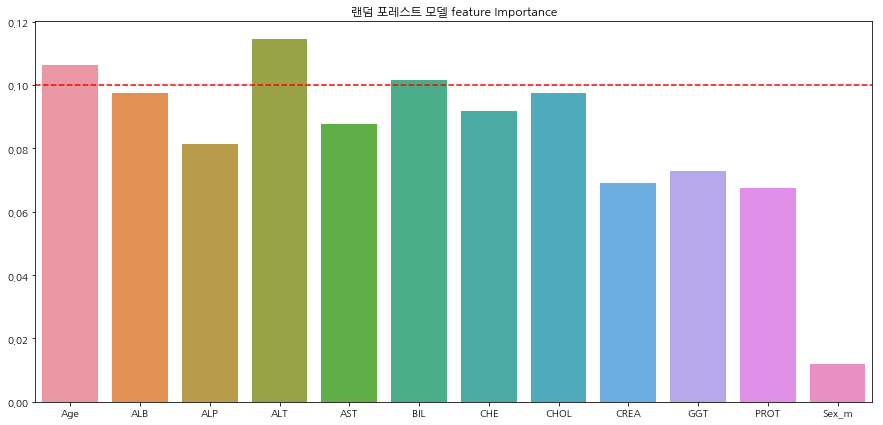

In [744]:
pca_param = rf.named_steps['preprocessor'].transformers_[0][1]['pca'].components_ #pca 계수: 6차원으로 축소
rf_imp = rf.named_steps['classifier'].feature_importances_ #7차원(범주형 변수 sex 추가)

# 3. 전환 행렬: (k, m) * (k, 1) → (m,)
#    각 원본feature의 importance = sum over PC [ (주성분 importance × loading^2) ]
original_imp = np.sum((pca_param**2) * rf_imp[:6][:, np.newaxis], axis=0)
original_imp= np.append(original_imp, rf_imp[-1]) #카테고리 추가

f_name = X.columns

plt.figure(figsize=(15, 7))
sns.barplot(x=f_name, y=original_imp)
plt.title('랜덤 포레스트 모델 feature Importance')
plt.axhline(y=0.1, color='r', ls='--')
plt.show()

pca 가중치 계수와 차원축소 후 주성분 축을 데이터로 받아 학습된 랜덤 포레스트의 feature importance 의 연산을 통해  
스케일링 이후 pca 전 원본 feature의 중요도를 복원 후 비교하였다.  
ALT, Age, BIL 순으로 모델 학습에 중요하게 기여하였다.  
따라서, ALT, Age, BIL 설명변수가 간염 정도 예측에 크게 기여한다고 볼 수 있다.

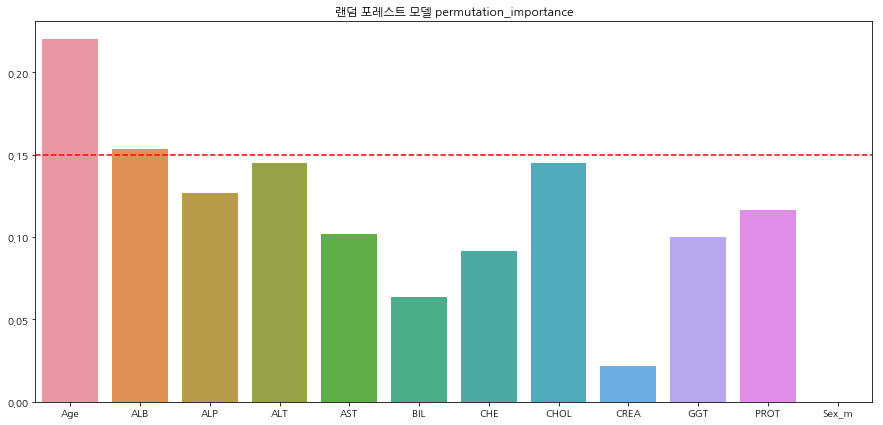

In [747]:
#참고
from sklearn.inspection import permutation_importance

f_imp = permutation_importance(rf, train_X, train_Y, n_repeats=10, random_state=42)
f = X.columns
imp = f_imp.importances_mean

f_name = X.columns

plt.figure(figsize=(15, 7))
sns.barplot(x=f_name, y=imp)
plt.title('랜덤 포레스트 모델 permutation_importance')
plt.axhline(y=0.15, color='r', ls='--')
plt.show()

## 4. 데이터 설명
- 데이터 출처 : https://www.data.go.kr/data/15048032/fileData.do / 후처리, 통계청 날씨정보
- 데이터 링크 : 
    - ./data/p2_sb_2021.csv
    - ./data/p2_sb_2022.csv
    - ./data/p2_sb_2023.csv
    - ./data/p2_w_2021.csv
    - ./data/p2_w_2022.csv
    - ./data/p2_w_2023.csv
- 데이터 설명 : 
    - 21년~23년의 J시의 2개 지하철호선 지하철의 시간대별 승하차 인원 정보 데이터 (p2_sb_년도.csv)
        - X5~ X22 : 5시부터 22시 승차 또는 하차 인원, (X5 : 05시의 계절 날짜와 대응)
        - 역번호 : 각 정류장의 고유 번호
        - 승하차구분 : 승차 또는 하차
    - 21년~23년의 J시의 특정지역구의 시간대별 게절성 정보 데이터 (p2_w_년도.csv)
        - 시간별 J시의 날씨정보 

In [36]:
p1 = pd.read_csv('https://raw.githubusercontent.com/Datamanim/datarepo/refs/heads/master/adp/33/data/p2_sb_2021.csv')
p2 = pd.read_csv('https://raw.githubusercontent.com/Datamanim/datarepo/refs/heads/master/adp/33/data/p2_sb_2022.csv')
p3 = pd.read_csv('https://raw.githubusercontent.com/Datamanim/datarepo/refs/heads/master/adp/33/data/p2_sb_2023.csv')
w1 = pd.read_csv('https://raw.githubusercontent.com/Datamanim/datarepo/refs/heads/master/adp/33/data/p2_w_2021.csv')
w2 = pd.read_csv('https://raw.githubusercontent.com/Datamanim/datarepo/refs/heads/master/adp/33/data/p2_w_2022.csv')
w3 = pd.read_csv('https://raw.githubusercontent.com/Datamanim/datarepo/refs/heads/master/adp/33/data/p2_w_2023.csv')

In [37]:
display(p1.head())
display(p2.head())
display(p3.head())
display(w1.head())
display(w2.head())
display(w3.head())

,날짜,호선,역번호,승하차구분,X5,X6,X7,X8,X9,X10,...,X13,X14,X15,X16,X17,X18,X19,X20,X21,X22
0,2021-01-01,A,201,승차,22.0,25,61,64,58,53,...,109,149,196,168,178,177,117,138,90,58
1,2021-01-01,A,201,하차,12.0,49,87,142,101,110,...,105,125,114,86,119,63,26,25,62,18
2,2021-01-01,A,202,승차,43.0,53,70,119,94,103,...,331,323,437,447,881,531,335,441,403,137
3,2021-01-01,A,202,하차,21.0,154,238,727,425,356,...,330,342,321,333,331,163,119,110,137,47
4,2021-01-01,A,203,승차,21.0,27,48,81,62,60,...,156,197,197,203,213,190,145,208,135,76


,날짜,호선,역번호,승하차구분,X5,X6,X7,X8,X9,X10,...,X13,X14,X15,X16,X17,X18,X19,X20,X21,X22
0,2022-01-01,A,201,승차,16.0,36,55,100,92,96,...,268,287,389,443,424,385,240,358,359,115
1,2022-01-01,A,201,하차,9.0,88,196,209,150,136,...,253,311,249,223,196,161,84,103,130,65
2,2022-01-01,A,202,승차,41.0,39,79,124,168,200,...,607,752,796,977,1377,1200,922,985,1094,417
3,2022-01-01,A,202,하차,38.0,156,220,707,564,529,...,776,801,828,837,861,649,328,245,403,176
4,2022-01-01,A,203,승차,24.0,36,72,70,105,263,...,439,413,409,395,497,475,377,581,689,212


,날짜,호선,역번호,승하차구분,X5,X6,X7,X8,X9,X10,...,X13,X14,X15,X16,X17,X18,X19,X20,X21,X22
0,2023-01-01,A,201,승차,43.0,43,43,138,140,287,...,482,527,601,627,761,801,581,507,503,304
1,2023-01-01,A,201,하차,36.0,126,144,245,283,348,...,403,432,450,371,354,308,227,232,237,208
2,2023-01-01,A,202,승차,108.0,111,120,175,278,556,...,1154,1258,1372,1556,1687,1901,1347,1333,1162,1029
3,2023-01-01,A,202,하차,114.0,312,387,869,899,773,...,1252,1236,1145,1319,1289,1082,874,732,612,414
4,2023-01-01,A,203,승차,52.0,69,107,238,244,553,...,880,806,774,847,748,714,554,508,423,366


,일시,기온,강수량,풍속,습도,증기압,현지기압,전운량,중하층운량,지면온도
0,2021-01-01 00:00,-8.3,NaN,1.8,66,2.2,1016.4,0.0,0,-6.8
1,2021-01-01 01:00,-8.7,NaN,2.4,68,2.2,1016.4,0.0,0,-6.9
2,2021-01-01 02:00,-9.1,NaN,1.6,69,2.1,1016.2,0.0,0,-7.1
3,2021-01-01 03:00,-9.3,NaN,1.1,70,2.1,1016.8,0.0,0,-7.3
4,2021-01-01 04:00,-9.3,NaN,0.3,71,2.2,1016.2,0.0,0,-7.5


,일시,기온,강수량,풍속,습도,증기압,현지기압,전운량,중하층운량,지면온도
0,2022-01-01 00:00,-8.5,NaN,1.9,41,1.3,1021.9,0,0,-7.0
1,2022-01-01 01:00,-9.2,NaN,1.8,42,1.3,1022.2,0,0,-7.2
2,2022-01-01 02:00,-9.5,NaN,1.2,43,1.3,1022.3,0,0,-7.5
3,2022-01-01 03:00,-9.3,NaN,1.4,46,1.4,1022.6,0,0,-7.6
4,2022-01-01 04:00,-9.6,NaN,1.7,48,1.4,1021.9,0,0,-7.6


,일시,기온,강수량,풍속,습도,증기압,현지기압,전운량,중하층운량,지면온도
0,2023-01-01 00:00,0.9,NaN,1.4,72,4.7,1018.5,9,9,-1.6
1,2023-01-01 01:00,1.5,NaN,1.9,71,4.9,1018.0,6,6,-1.4
2,2023-01-01 02:00,1.5,NaN,1.9,72,4.9,1017.8,9,8,-1.6
3,2023-01-01 03:00,1.6,NaN,1.6,74,5.1,1018.1,8,8,-1.8
4,2023-01-01 04:00,1.5,NaN,1.4,74,5.0,1018.1,9,9,-1.3


## 4-1 아래 조건들을 참고하여 전처리를 시행하고 훈련데이터에 대한 기초통계량을 구하시오
1. 승하차 데이터에서 X5~X22 모든컬럼이 0의 값을 가지는 경우 해당 날짜,호선,역번호 승하차 행은 제외한다. 
2. 승하차 데이터를 날짜,호선,역번호,시간대별(05~22시) 승객수의 총합을 구하여라(승차 + 하차), 결측치는 0명으로 간주한다. 컬럼명은 users로 변경한다.
3. 날짜 데이터의 강수 데이터는 결측치를 0, 그 외 컬럼의 결측치는 직전값으로 대치한다.
4. 날짜데이터와 일자,시간별 승하차인원 데이터를 동일날짜,시간에 대해 합친다.
5. 일자정보를 바탕으로 주말 여부를 나타내는 weekday컬럼을 추가한다. (주말=1,평일=0)
6. 21년,22년 데이터는 훈련데이터, 23년 데이터는 테스트 데이터로 사용한다.

In [38]:
#일단 데이터프레임 별로 연도별 데이터 병합
p = pd.concat([p1, p2, p3], axis=0).reset_index(drop=True)
w = pd.concat([w1, w2, w3], axis=0).reset_index(drop=True)

In [39]:
display(p.head(2))
display(w.head(2))

,날짜,호선,역번호,승하차구분,X5,X6,X7,X8,X9,X10,...,X13,X14,X15,X16,X17,X18,X19,X20,X21,X22
0,2021-01-01,A,201,승차,22.0,25,61,64,58,53,...,109,149,196,168,178,177,117,138,90,58
1,2021-01-01,A,201,하차,12.0,49,87,142,101,110,...,105,125,114,86,119,63,26,25,62,18


,일시,기온,강수량,풍속,습도,증기압,현지기압,전운량,중하층운량,지면온도
0,2021-01-01 00:00,-8.3,NaN,1.8,66,2.2,1016.4,0.0,0,-6.8
1,2021-01-01 01:00,-8.7,NaN,2.4,68,2.2,1016.4,0.0,0,-6.9


In [40]:
#승하차 데이터에서 X5~X22 모든컬럼이 0의 값을 가지는 경우 해당 날짜,호선,역번호 승하차 행은 제외
x_cols = p.select_dtypes('number').columns[1:]
pp = p[~(p[x_cols] == 0).all(axis=1)] #0값 레코드 삭제

#승하차 데이터를 날짜,호선,역번호,시간대별(05~22시) 승객수의 총합(승차 + 하차), 결측치는 0명. 컬럼명은 users로 변경
pp = pp.fillna(0)
pp = pp.groupby(['날짜', '호선', '역번호'])[x_cols].sum().reset_index() #승하차 합
pp['users'] = pp[x_cols].sum(axis=1).astype(int)
display(pp.head(5))

#날짜 데이터의 강수 데이터는 결측치를 0, 그 외 컬럼의 결측치는 직전값으로 대치
w['강수량'] = w['강수량'].fillna(0)
w = w.fillna(method='ffill')
display(w.head(5))

#날짜데이터와 일자,시간별 승하차인원 데이터를 동일날짜,시간에 대해 합침
tmp1 = pd.melt(pp, id_vars=['날짜','호선', '역번호', 'users'], var_name='시간', value_name='시간별 승객수')
tmp1['시간'] = tmp1['시간'].str.replace('X', '').astype(int)

tmp2 = w.copy()
tmp2['일시'] = pd.to_datetime(tmp2['일시'], format='%Y-%m-%d %H:%M')
tmp2['날짜'] = tmp2['일시'].dt.strftime('%Y-%m-%d')
tmp2['시간'] = tmp2['일시'].dt.hour

total = pd.merge(tmp1, tmp2, on=['날짜', '시간'], how='left').sort_values(by=['날짜', '시간', '호선', '역번호', 'users', '시간'])
display(total.head(5))

#일자정보를 바탕으로 주말 여부를 나타내는 weekday컬럼을 추가한다. (주말=1,평일=0)
total['weekend'] = np.where(total['일시'].dt.weekday.isin([5, 6]), 1, 0)
total[['역번호', '시간', 'weekend']] = total[['역번호', '시간', 'weekend']].astype('object')
display(total.head(2))

#21년,22년 데이터는 훈련데이터, 23년 데이터는 테스트 데이터로 사용
train = total[total['일시'].dt.year.isin(['2021', '2022'])]
test = total[total['일시'].dt.year.isin(['2023'])]

train.drop(columns=['일시'], inplace=True)
test.drop(columns=['일시'], inplace=True)

train.shape, test.shape

,날짜,호선,역번호,X5,X6,X7,X8,X9,X10,X11,...,X14,X15,X16,X17,X18,X19,X20,X21,X22,users
0,2021-01-01,A,201,34.0,74,148,206,159,163,178,...,274,310,254,297,240,143,163,152,76,3302
1,2021-01-01,A,202,64.0,207,308,846,519,459,553,...,665,758,780,1212,694,454,551,540,184,10101
2,2021-01-01,A,203,39.0,102,171,238,181,178,242,...,392,397,381,368,288,211,271,205,104,4480
3,2021-01-01,A,204,23.0,89,73,140,117,156,178,...,253,263,231,205,181,115,118,104,37,2728
4,2021-01-01,A,205,67.0,140,221,315,346,356,453,...,521,615,555,601,480,340,370,390,155,6870


,일시,기온,강수량,풍속,습도,증기압,현지기압,전운량,중하층운량,지면온도
0,2021-01-01 00:00,-8.3,0.0,1.8,66,2.2,1016.4,0.0,0,-6.8
1,2021-01-01 01:00,-8.7,0.0,2.4,68,2.2,1016.4,0.0,0,-6.9
2,2021-01-01 02:00,-9.1,0.0,1.6,69,2.1,1016.2,0.0,0,-7.1
3,2021-01-01 03:00,-9.3,0.0,1.1,70,2.1,1016.8,0.0,0,-7.3
4,2021-01-01 04:00,-9.3,0.0,0.3,71,2.2,1016.2,0.0,0,-7.5


,날짜,호선,역번호,users,시간,시간별 승객수,일시,기온,강수량,풍속,습도,증기압,현지기압,전운량,중하층운량,지면온도
0,2021-01-01,A,201,3302,5,34.0,2021-01-01 05:00:00,-9.7,0.0,1.9,72,2.1,1015.6,0.0,0,-7.6
1,2021-01-01,A,202,10101,5,64.0,2021-01-01 05:00:00,-9.7,0.0,1.9,72,2.1,1015.6,0.0,0,-7.6
2,2021-01-01,A,203,4480,5,39.0,2021-01-01 05:00:00,-9.7,0.0,1.9,72,2.1,1015.6,0.0,0,-7.6
3,2021-01-01,A,204,2728,5,23.0,2021-01-01 05:00:00,-9.7,0.0,1.9,72,2.1,1015.6,0.0,0,-7.6
4,2021-01-01,A,205,6870,5,67.0,2021-01-01 05:00:00,-9.7,0.0,1.9,72,2.1,1015.6,0.0,0,-7.6


,날짜,호선,역번호,users,시간,시간별 승객수,일시,기온,강수량,풍속,습도,증기압,현지기압,전운량,중하층운량,지면온도,weekend
0,2021-01-01,A,201,3302,5,34.0,2021-01-01 05:00:00,-9.7,0.0,1.9,72,2.1,1015.6,0.0,0,-7.6,0
1,2021-01-01,A,202,10101,5,64.0,2021-01-01 05:00:00,-9.7,0.0,1.9,72,2.1,1015.6,0.0,0,-7.6,0


((1090620, 16), (545616, 16))

In [41]:
# train_set 통계량 확인
print("연속형 변수")
display(train.describe().T)

print("명목형 변수")
display(train.describe(include='object').T)

연속형 변수


,count,mean,std,min,25%,50%,75%,max
users,1090620.0,37689.791005,32057.394419,501.0,14453.000,27338.5,50749.0,237299.0
시간별 승객수,1090620.0,2093.877278,2346.067281,0.0,597.000,1347.0,2732.0,26183.0
기온,1090620.0,14.176355,11.175155,-18.5,6.000,15.4,23.6,36.3
강수량,1090620.0,0.171750,1.440923,0.0,0.000,0.0,0.0,64.7
풍속,1090620.0,2.481560,1.134005,0.0,1.700,2.3,3.1,8.6
습도,1090620.0,62.749391,18.919553,17.0,48.000,62.0,78.0,100.0
증기압,1090620.0,12.654094,8.796690,0.7,5.375,9.9,19.7,35.2
현지기압,1090620.0,1005.940944,8.094596,984.1,999.400,1006.3,1012.3,1025.8
전운량,1090620.0,4.974505,3.956197,0.0,0.000,6.0,9.0,10.0
중하층운량,1090620.0,3.064764,3.459133,0.0,0.000,1.0,7.0,10.0


명목형 변수


,count,unique,top,freq
날짜,1090620,730,2022-01-22,1494
호선,1090620,2,A,657000
역번호,1090620,83,342,13140
시간,1090620,18,22,60590
weekend,1090620,2,0,778374


## 4-2 전체 년도 데이터에 대해 users와 날씨 정보에 대해 상관관계를 분석하고 주말여부에 따른 users 변수의 차이가 존재하는지 통계적으로 확인하라.

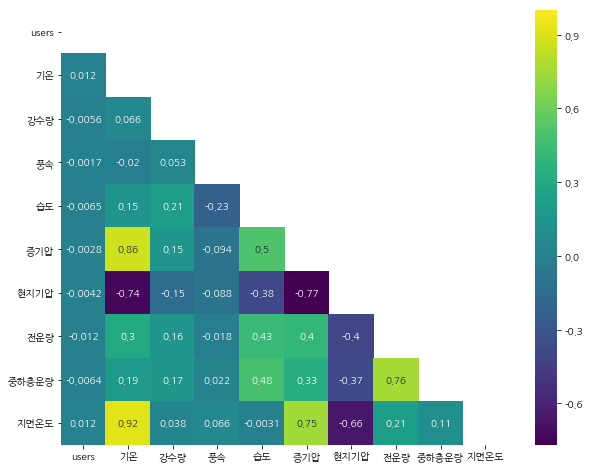

In [42]:
#users와 날씨정보 상관관계 분석
w_cols = ['users', '기온', '강수량', '풍속', '습도', '증기압', '현지기압', '전운량', '중하층운량', '지면온도']

plt.figure(figsize=(10, 8))
corr = total[w_cols].corr()
mask = np.triu(np.ones_like(corr, dtype='bool'))
sns.heatmap(corr, mask=mask, annot=True, cmap='viridis')
plt.show()

users와 계절컬럼의 피어슨 상관관계를 확인한 결과, 유의미한 상관관계가 존재하지 않는 것을 확인할 수 있다.   
다음으로 주말여부에 따른 users 변수의 차이가 있는지 통계적으로 검정한다.  
주말여부는 이진 명목변수이며, users는 연속형 변수이다.  
평일과 주말이 동시에 존재할 수 없으므로 두 그룹은 독립표본이다.  
모수검정이 가능하면(정규성 만족) 독립표본 t-test(등분산성 만족), Welch's t-test(등분산성 만족x),  
모수검정이 가능하지 않다면 비모수 검정방식인 Mann-Whitney U test를 실시한다. 

따라서, 검정방식을 확인하기 위해 먼저 shapiro 검정으로 정규성을 확인하고, levene 검정으로 등분산성을 확인한다.  
모든 검정 및 가설은 유의확률 5% 하에서 실시한다. 

In [43]:
from scipy.stats import shapiro, levene

g1 = total[total['weekend'] == 0]['users'] #주말아님
g2 = total[total['weekend'] == 1]['users'] # 주말

g = [('평일', g1), ('주말', g2)]

rs = pd.DataFrame(columns=['평일_p', '주말_p', '등분산p', '정규성만족여부', '등분산만족여부'])
s = [] #샤피로 결과


for name, group in g:
    stats, p = shapiro(group)
    s.append(p)
stats, p = levene(g1, g2)
s_ok = ['O' if (s[0] >= 0.05) & (s[1] >= 0.05) else 'X']
l_ok = ['O' if p >= 0.05 else 'X']
rs.loc[len(rs)] = s+[p]+s_ok+l_ok
display(rs)

,평일_p,주말_p,등분산p,정규성만족여부,등분산만족여부
0,0.0,0.0,0.0,X,X


정규성을 만족하지 않으므로 모수검정인 독립표본 t-test를 사용할 수 없다.   
따라서 비모수방식인 Mann-Whitney U test를 실시한다. 

<가설수립: 유의확률 5% 하>
- H0: 주말여부에 따라 users 값 차이가 없다.
- H1: 주말여부에 따라 users 값 차이가 있다.

In [44]:
from scipy.stats import mannwhitneyu

stats, p = mannwhitneyu(g1, g2)

print(f"Mann-Whitney U 검정 통계량: {stats} / p-value: {p:.3f}")
print("주말여부에 따라 users값 차이가", "있다." if p < 0.05 else "없다")

Mann-Whitney U 검정 통계량: 366333219702.0 / p-value: 0.000
주말여부에 따라 users값 차이가 있다.


검정결과 주말여부에 따른 users 값 차이가 있으므로 분류모형 구축 후 학습을 통해 두 클래스를 분류할 수 있을 것이다.

## 4-3 users를 예측하는 2가지 회귀모델을 학습하고 모델에 대해 평가하라 (선형회귀 모델은 1개 필수 포함)

In [45]:
train.select_dtypes('O')

,날짜,호선,역번호,시간,weekend
0,2021-01-01,A,201,5,0
1,2021-01-01,A,202,5,0
2,2021-01-01,A,203,5,0
3,2021-01-01,A,204,5,0
4,2021-01-01,A,205,5,0
...,...,...,...,...,...
1605919,2022-12-31,B,338,22,1
1605920,2022-12-31,B,339,22,1
1605921,2022-12-31,B,340,22,1
1605922,2022-12-31,B,341,22,1


- Linear Regression: 기본적인 선형모델, 종속변수 예측값을 y로 두고 설명변수와 가중치가 되는 계수를 학습을 통해 정해서 선형식으로   
  만든 다음 오차를 최소화하는 방식으로 하이퍼파라미터를 최적화 후 예측
- Random Forest Regression: 앙상블 트리모델

In [52]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

#데이터가 너무 많아서 오류가 남 만개만 쌤플링
train = train.sample(10000) 
test = train.sample(2000) 
train_X = train.drop(columns=['users', '날짜', '시간별 승객수'])
train_Y = train['users']
test_X = test.drop(columns=['users', '날짜', '시간별 승객수'])
test_Y = test['users']

cat_cols = train_X.select_dtypes('O').columns
n_cols = train_X.select_dtypes('number').columns

#다중공선성 방지를 위해 첫번째 컬럼 삭제
train_X = pd.get_dummies(train_X, columns=cat_cols, drop_first=True)
test_X = pd.get_dummies(test_X, columns=cat_cols, drop_first=True)

#거리기반 모델용
pre_processor = ColumnTransformer([
    ('num_scaler', StandardScaler(), n_cols)], remainder='passthrough')

lr = Pipeline([
    ('preprocessor', pre_processor), 
    ('lr', LinearRegression())
])

rf = RandomForestRegressor(random_state=42)

lr.fit(train_X, train_Y)
rf.fit(train_X, train_Y)

RandomForestRegressor(random_state=42)

In [55]:
train_X.head(3)

,기온,강수량,풍속,습도,증기압,현지기압,전운량,중하층운량,지면온도,호선_B,...,시간_14,시간_15,시간_16,시간_17,시간_18,시간_19,시간_20,시간_21,시간_22,weekend_1
1227019,21.2,11.8,3.5,100,25.0,1000.9,10.0,7,21.8,1,...,0,0,0,0,1,0,0,0,0,0
661642,14.1,0.0,2.9,63,10.1,1012.0,3.0,3,23.4,0,...,0,0,0,0,0,0,0,0,0,0
1203879,25.4,0.0,1.9,55,17.7,1011.5,1.0,1,23.0,1,...,0,0,0,0,1,0,0,0,0,0


In [56]:
from sklearn.metrics import r2_score, mean_squared_error

md_list = [('선형회귀', lr), ('랜덤포레스트', rf)]
dt_list = [('train', train_X, train_Y), ('test', test_X, test_Y)]

rs = pd.DataFrame(columns=['model_name', 'data_name', 'r2', 'mse', 'rmse'])

for m_name, model in md_list:
    for name, x, y in dt_list:
        pred = model.predict(x)
        r2 = r2_score(y, pred)
        mse = mean_squared_error(y, pred)
        rs.loc[len(rs)] = [m_name, name, r2, mse, np.sqrt(mse)]
display(rs)

,model_name,data_name,r2,mse,rmse
0,선형회귀,train,0.876010,1.286281e+08,11341.430913
1,선형회귀,test,0.876114,1.335235e+08,11555.235285
2,랜덤포레스트,train,0.987929,1.252299e+07,3538.783673
3,랜덤포레스트,test,0.989089,1.175973e+07,3429.246125


R2(설명력), rmse, mse를 평가지표로 두 모델의 성능을 평가하였다.  
두 모델 모두 90% 이상의 설명력을 가지고 있으며, train/test set의 성능이 비슷하므로 과적합은 없었다.  
R2, mse, rmse 지표를 보았을 때 랜덤포레스트의 성능이 비교군인 선형회귀보다 확연하게 좋았다. 

# 통계 (40점)

## 데이터 설명
- 데이터 출처 : 자체 제작
- 데이터 링크 : ./data/s1.csv
- 데이터 설명 : A,B 두 공장의 특정 일자의 수율(%)데이터. 단, 불량률은 (100 - 수율)로 정의한다.
    

In [2]:
dt5 = pd.read_csv('https://raw.githubusercontent.com/Datamanim/datarepo/refs/heads/master/adp/33/data/s1.csv')
print(dt5.info())
display(dt5.head(3))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   year    50 non-null     int64  
 1   month   50 non-null     object 
 2   day     50 non-null     int64  
 3   A       45 non-null     float64
 4   B       45 non-null     float64
dtypes: float64(2), int64(2), object(1)
memory usage: 2.1+ KB
None


,year,month,day,A,B
0,2023,Sep,7,56.9,42.3
1,2023,Feb,20,100.0,89.0
2,2023,Jun,15,19.3,59.0


In [4]:
dt5[(dt5['A'].isnull()) | (dt5['B'].isnull())]

,year,month,day,A,B
7,2023,Nov,26,NaN,68.8
9,2023,Mar,23,NaN,87.4
12,2023,Jun,24,35.6,NaN
16,2023,Dec,24,65.6,NaN
28,2023,Oct,12,32.3,NaN
29,2023,Nov,26,NaN,60.1
30,2023,Jul,22,NaN,69.1
35,2023,Sep,27,50.1,NaN
39,2023,Sep,16,NaN,60.7
48,2023,Sep,5,30.6,NaN


info에서 확인하였을 때 A, B 공장의 수율 결측치가 각각 5개씩 관찰된다.(총 10개 레코드)  
A, B 공장의 데이터는 각각 독립적이며, 임의일자에 측정한 데이터로 데이터들 간에도 독립적이기 때문에 대표값이나, 전/후위 결측치 보간이  
적절하지 않다. 따라서 10개 레코드를 삭제한다.

In [8]:
dt5 = dt5.dropna()
len(dt5)

40

## 5-1 공장별 불량률 차이 평균, 표준편차를 제시하시오.

In [12]:
#불량률: 100-수유
dt5['불량률A'] = 100 - dt5['A']
dt5['불량률B'] = 100 - dt5['B']

#A-B
dt5['불량률차이'] = dt5['불량률B'] - dt5['불량률A']

print(f"공장 불량률 차이 평균: {dt5['불량률차이'].mean()}")
print(f"공장 불량률 차이 표준편차: {dt5['불량률차이'].std()}")

공장 불량률 차이 평균: 5.274999999999999
공장 불량률 차이 표준편차: 22.341277768017036


B공장의 불량률이 A공장의 불량률보다 5.274999999999999% 높다.   
표준편차가 22.341277768017036로 높다. 이는 두 공장 간의 불량률의 차이가 일관적이지 않고 변동성이 크다는 것을 의미하며,   
B공장의 불량률이 더 높다고 단정하기보다는 데이터의 변동성을 고려한 추가적인 분석이 필요하다.

## 5-2. A,B 공장의 불량률 평균 차이가 존재하는지 확인하려 한다. 귀무,대립 가설을 설정하고 설명하라

두 공장의 불량률 평균 차이가 존재하는지 확인하기 위해서는 데이터가 정규성, 등분산성, 독립성(여기서는 독립표본)을 만족하는 경우   
모수검정인 독립표본 t-test, 이를 만족하지 않는다면 비모수검정인 Mann-Whitney U 검정을 실시한다.  

모수, 비모수 검정을 선택하기 위해 정규성 검정을 실시하고, 등분산 여부를 확인하기 위해 등분산성 검정을 실시한다.  

<정규성 검정가정:유의수준 0.05 하>
- H0: 0공장 불량률 데이터는 정규성을 만족한다.   
- H1: 0공장 불량률 데이터는 정규성을 만족하지 않는다.  

<등분산성 검정 가정: 유의수준 0.05 하>
- H0: 두 공장의 불량률 분포는 등분산이다. 
- H1: 두 공장의 불량률 분포는 등분산이 아니다.

In [24]:
from scipy.stats import anderson, jarque_bera, ks_2samp, probplot
ks_2samp(dt5['불량률A'], dt5['불량률B'])

KstestResult(statistic=0.325, pvalue=0.02860307028023343)

,name,stats_A,stats_B,pvalue_A,pvalue_B
0,Jarque-bera,0.883017,0.281989,2.332808e-01,6.454001e-01
1,K-S,0.883017,0.281989,3.236272e-24,1.818989e-52


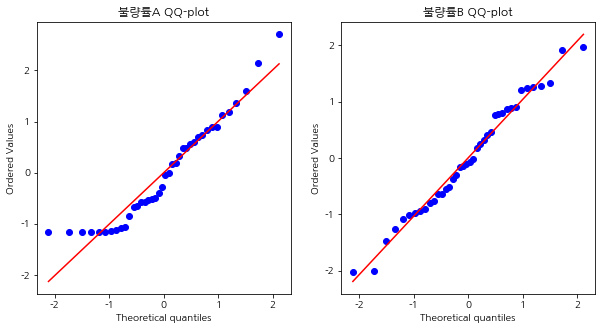

정규성 검정결과: A공장(0.000), B공장(0.000)로 유의확률 5% 하 귀무가설을 기각(정규성x)
등분산성 검정결과: p-value 0.019로 귀무가설을 기각(등분산성x)


In [35]:
from scipy.stats import shapiro, levene

#정규성 검정
s_stats1, p1 = shapiro(dt5['불량률A'])
s_stats2, p2 = shapiro(dt5['불량률B'])

#정규성: 기타
from scipy.stats import jarque_bera, kstest, probplot, zscore, norm

rs = pd.DataFrame(columns=['name', 'stats_A', 'stats_B', 'pvalue_A', 'pvalue_B'])
m_list = [jarque_bera, kstest]
m_title = ['Jarque-bera', 'K-S'] 

for name, m in zip(m_title, m_list):
    if name == 'K-S':
        stst1, p1 = m(dt5['불량률A'], cdf=norm.cdf)
        stst2, p2 = m(dt5['불량률B'], cdf=norm.cdf)
    else:
        stst1, p1 = m(dt5['불량률A'])
        stst2, p2 = m(dt5['불량률B'])
    rs.loc[len(rs)] = [name, stat1, stat2, p1, p2]
display(rs)    

z1 = zscore(dt5['불량률A'])
z2 = zscore(dt5['불량률B'])
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
probplot(z1, plot=ax[0])
probplot(z2, plot=ax[1])
ax[0].set_title('불량률A QQ-plot')
ax[1].set_title('불량률B QQ-plot')
plt.show()

#등분산성
l_stat, lp = levene(dt5['불량률A'], dt5['불량률B'])

print(f"정규성 검정결과: A공장({p1:.3f}), B공장({p2:.3f})로 유의확률 5% 하 귀무가설을", "기각(정규성x)" if(p1 < 0.05) | (p2 < 0.05) else "기각x(정규성)")
print(f"등분산성 검정결과: p-value {lp:.3f}로 귀무가설을", "기각(등분산성x)" if lp < 0.05 else "기각x(등분산성)")

정규성(A공장 불량률)을 만족하지 못하기 때문에 모수검정을 사용하지 못하여 비모수 검정인 Mann-Whitney U 검정을 실시한다.  

<유의확률 5% 하 가설수립>
- H0: 두 공장의 불량률 평균 차이가 없다. 
- H1: 두 공장의 불량률 평균 차이가 있다.

## 5-3. A,B의 차이가 있는지 통계검정 하고 설명하라

In [40]:
from scipy.stats import mannwhitneyu

stat, p = mannwhitneyu(dt5['불량률A'], dt5['불량률B'], alternative = 'two-sided')

print(f"Mann-Whitney U 검정 U 통계량: {stat:.3f}")
print(f"유의확률 5% 하 p-value가 {p:.3f}로 귀무가설을", "기각(차이있음)" if p < 0.05 else "기각x(차이없음)")

Mann-Whitney U 검정 U 통계량: 630.500
유의확률 5% 하 p-value가 0.104로 귀무가설을 기각x(차이없음)


유의확률 5% 하 p-value 0.104로 크므로 귀무가설을 기각할 수 없다.  
따라서, A공장 불량률과 B공장 불량률 간 통계적으로 유의미한 차이가 없다. 

## 데이터 설명
- 데이터 출처 : https://www.data.go.kr/data/15123586/fileData.do 후처리
- 데이터 링크 : ./data/s2.csv
- 데이터 설명 : 일자별 지하철 노선별 지연 데이터

In [170]:
dt6 =  pd.read_csv('https://raw.githubusercontent.com/Datamanim/datarepo/refs/heads/master/adp/33/data/s2.csv')
print(dt6.info())
display(dt6.head(3))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 833 entries, 0 to 832
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   지연ID    833 non-null    object
 1   지연일자    833 non-null    object
 2   노선      833 non-null    object
 3   최대지연시간  833 non-null    object
dtypes: object(4)
memory usage: 26.2+ KB
None


,지연ID,지연일자,노선,최대지연시간
0,ID_0,2023-09-01,1호선,15분
1,ID_1,2023-09-01,1호선,15분
2,ID_2,2023-09-01,4호선,10분


## 6-1. 노선에 상관없이 일별 최대 지연시간이 5~15분으로 발생하는 경우는 하나의 사건으로 보자.  해당 사건이 일자별 발생하는 빈도가 포아송분포를 따르는지 확인하는 방법 2가지를 기술하고 결과를 보여라

In [171]:
# 일단 데이터 가공
r_dt6 = dt6.copy()
r_dt6['최대지연시간'] = r_dt6['최대지연시간'].str.replace(r'분 이상|분', '', regex=True).astype(int)
r_dt6['해당'] = np.where(r_dt6['최대지연시간'].between(5, 15), 1, 0)
p_count = r_dt6.groupby('지연일자')['해당'].sum()
display(p_count.head())
print(f"원본 사이즈: {len(dt6['지연일자'].value_counts())}, 가공 사이즈 {len(p_count)}")

지연일자
2023-09-01    4
2023-09-04    2
2023-09-05    3
2023-09-06    4
2023-09-08    4
Name: 해당, dtype: int32

원본 사이즈: 256, 가공 사이즈 256


"분포"에 따른 적합성을 검정하는 것이기 때문에, 카이제곱 적합도 검정과 Kolmogorov-Smirnov(K-S) 검정을 사용한다. .

- 카이제곱 적합도 검정(Goodness of fit test): 관측값들이 어떤 이론이나 이론적 분포를 따르고 있는지 검정(기대도수 5이상)

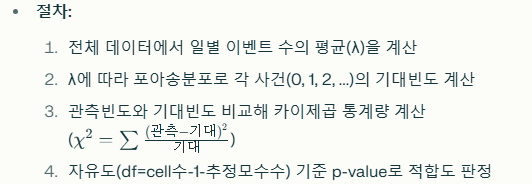

- Kolmogorov-Smirnov(K-S): 누적분포함수(CDF) 기반으로 관측값과 포아송분포의 전체 분포 형태가 얼마나 다른지를 측정

<절차> 
- 전체 데이터의 일별 이벤트 빈도를 정렬, 경험누적분포(Fn) 계산
- 같은 λ로 포아송분포 누적분포(F0) 계산
- 두 분포의 차이 중 최대값이 임계값(유의수준 α)보다 크면 “적합하지 않음”으로 판정

<유의확률 5% 하 가설수립>
- H0: 데이터는 포아송 분포를 따른다. 
- H1: 데이터는 포아송 분포를 따르지 않는다.

**왜 카이제곱과 K-S 검정을 써야하는가?**
1. 카이제곱 검정:  
  → 관측 빈도 데이터(“각 사건별 발생 횟수”)가 “이산적 이론분포(포아송)”에 유의하게 적합한지 양적으로 판단  
  → 각 사건 건수(0회, 1회, 2회, …)별 분할표로 직접 해석할 수 있어 “도수 기반 적합도 검증”에 최적화  
2. K-S 검정:  
  → 누적분포 전체(패턴)가 실제와 이론 값 간에 얼마나 괴리되는지 전체적으로 평가  
  → 표본이 적거나, “빈도분포”가 아닌 “순위(누적)”를 중시할 때 좋은 기준  
  → 특히, 데이터가 연속형이거나 구간별 구분이 애매할 때 강점  

In [175]:
from scipy.stats import poisson, chisquare, kstest

#1. 카이제곱 적합도검정
lamb = p_count.mean() #평균계산
obs_freq = p_count.value_counts().sort_index() #사건수별 빈도
expected_freq = [len(p_count) * poisson.pmf(k, lamb) for k in obs_freq.index] # 각 사건(수)별 기대빈도
expected_freq = np.array(expected_freq)*obs_freq.sum() / sum(expected_freq) # 기대 도수를 관측 총합에 맞춰 정규화
cstat, p1 = chisquare(obs_freq.values, expected_freq) #사건수별 빈도, 각 사건(수)별 기대빈도

print(f"카이제곱 적합도 검정 통계량: {cstat}")
print(f"카이제곱 적합도 검정 p-value: {p1} 으로 귀무가설", "기각(포아송x)" if p1<0.05 else "기각x(포아송)")

카이제곱 적합도 검정 통계량: 132.55667454905526
카이제곱 적합도 검정 p-value: 8.345434412211419e-25 으로 귀무가설 기각(포아송x)


위에서 카이제곱 적합도검정을 실시하였지만, 기대도수가 5이하인 값이 있어 포아송 분포 검정에 적합하지 않다.   
다음으로 k-s 검정을 실시한다. 

In [177]:
#ks 검정
kstats, p2 = kstest(p_count, cdf='poisson', args=(lamb, )) #args는 튜플이어야 함

print(f"K-S 검정 통계량: {kstats}")
print(f"K-S 검정 p-value: {p2} 으로 귀무가설", "기각(포아송x)" if p2<0.05 else "기각x(포아송)")

K-S 검정 통계량: 0.36068538573222353
K-S 검정 p-value: 2.4645849459712848e-30 으로 귀무가설 기각(포아송x)


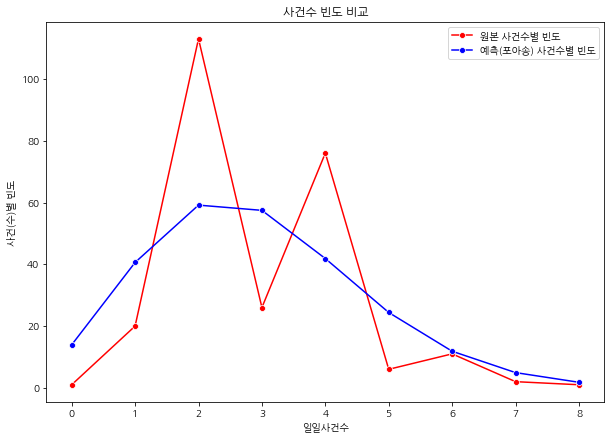

In [181]:
#시각화
fig, ax = plt.subplots(1, 1, figsize=(10, 7))
sns.lineplot(x=obs_freq.index, y=obs_freq, ax = ax, marker='o', color='r', label='원본 사건수별 빈도')
sns.lineplot(x=obs_freq.index, y=expected_freq, ax=ax, marker='o', color='b', label='예측(포아송) 사건수별 빈도')
ax.set_title('사건수 빈도 비교')
ax.set_xlabel('일일사건수')
ax.set_ylabel('사건(수)별 빈도')
plt.show()

K-S 검정결과, 유의확률 5% 하에서 p-value 2.4645849459712848e-30로 귀무가설을 기각할 수 없다.  
따라서 일자별 사건빈도수는 포아송 분포를 따르지 않는다.

**기타**: 해석 어려움
- Anderson-Darling(A-D) 검정: 데이터 순위를 매기고, 포아송분포의 CDF와의 차이에 가중치를 두어 통계량을 산출
  - 특징: 분포의 꼬리, 즉 극단값 영역 적합성을 더 엄격하게 평가합니다(단, 공식적 p-value 해석은 어렵고 보조지표로 주로 활용

In [204]:
# Anderson-Darling
cdf_vals = poisson.cdf(np.sort(p_count), lamb) #누적분포

# log(0) 방지: CDF, 1-CDF 값이 0 또는 1이 되지 않도록 소수점 보정(clip)
eps = 1e-10
cdf_vals = np.clip(cdf_vals, eps, 1 - eps)
one_minus_cdf = 1 - cdf_vals[::-1]
one_minus_cdf = np.clip(one_minus_cdf, eps, 1 - eps)

# 4. A-D 통계량 계산
n = len(p_count) #사건수(=일자수)
i = np.arange(1, n+1) #사건 index
ad_stat = -n - np.mean((2*i - 1) * (np.log(cdf_vals) + np.log(one_minus_cdf)))
print(f"Anderson-Darling 통계량: {ad_stat:.4f}")

Anderson-Darling 통계량: 29.4932


## 6-2. 지연시간을 지연정도로 분류하라.  호선별 지연정도를 교차표로 구하여라.

- 10분 이하: 1
- 10분 초과-20분 이하: 2
- 20분 초과: 3

In [222]:
cond1 = dt6['최대지연시간'].str.replace(r"분 이상|분", "", regex=True).astype(int) > 20
cond2 = (dt6['최대지연시간'].str.replace(r"분 이상|분", "", regex=True).astype(int) > 10) & (dt6['최대지연시간'].str.replace(r"분 이상|분", "", regex=True).astype(int) <= 20) 
dt6['지연정도'] = np.where(cond1, '20분 초과', np.where(cond2, "10분 초과 - 20분 이하", "10분 이하"))
cr = pd.crosstab(dt6['노선'], dt6['지연정도'])
display(cr)

지연정도,10분 이하,10분 초과 - 20분 이하,20분 초과
노선,,,
1호선,269,67,16
4호선,324,144,13


## 6-3. 지하철 호선별로 지연정도가 차이가 있는지 확인하려한다. 귀무가설과 대립가설을 설정한 후 통계 검정을 실시하라

하나의 모집단의 호선 별(샘플별) 지연정도 차이 여부의 검정은 카이제곱 독립성 검정을 실시한다.   
유의확률 5% 하 검정을 실시한다.  

<가설수립>
- H0: 지하철 호선 별 지연정도의 차이가 없다.(지하철 노선과 지연정도는 독립)
- H1: 지하철 호선 별 지연정도의 차이가 있다.(지하철 노선과 지연정도는 독립이 아님)

In [224]:
from scipy.stats import chi2_contingency

stats, p, ddof, expected = chi2_contingency(cr)

print(f"카이제곱 검정통계량: {stats:.3f}, p-value: {p:.3f}")
print(f"유의확률 5% 하 귀무가설을", "기각(차이있음)" if p<0.05 else "기각x(차이없음)")

카이제곱 검정통계량: 13.866, p-value: 0.001
유의확률 5% 하 귀무가설을 기각(차이있음)


유의확률 5% 하 귀무가설을 기각하였으므로 지하철 호선별 지연정도의 차이가 있다. 

## 문제 7
## 데이터 설명
- 데이터 출처 : 자체제작
- 데이터 링크 : ./data/s3.csv
- 데이터 설명 : 시계열 정보를 가지는 250행의 데이터

In [226]:
dt7 = pd.read_csv('https://raw.githubusercontent.com/Datamanim/datarepo/refs/heads/master/adp/33/data/s3.csv'\
                 , header=None)

print(dt7.info())
dt7.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       250 non-null    float64
dtypes: float64(1)
memory usage: 2.1 KB
None


,0
0,0.496714
1,0.308778
2,0.692133
3,2.070861
4,1.326845


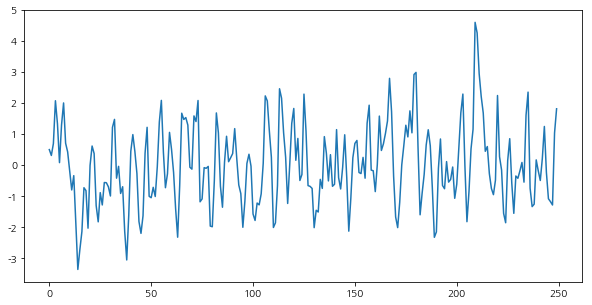

In [228]:
dt7.plot(figsize=(10, 5), legend=False)
plt.show()

## 7-1 ar ma arma에 대해 설명하고, ACF, PACF는 패턴을 통해 설명하라.

AR, MA, ARMA 모두 정상 시계열을 전제로 모델링하며, ACF/PACF 패턴을 보기 전에 시계열 정상화 필요

### 1. **AR (자기회귀, AutoRegressive)**

- **정의:**  
  과거 자신의 값들(시점별 lag 값)의 선형 조합으로 현재 값을 예측하는 모델  
  $$ X_t = \phi_1 X_{t-1} + \phi_2 X_{t-2} + \cdots + \phi_p X_{t-p} + \epsilon_t $$
  - $ p $: AR 차수(몇 시점 전까지 반영?)


### 2. **MA (이동평균, Moving Average)**

- **정의:**  
  과거 오차항의 선형 조합으로 현재 값을 예측하는 모델  
  $$ X_t = \epsilon_t + \theta_1 \epsilon_{t-1} + \cdots + \theta_q \epsilon_{t-q} $$
  - $ q $: MA 차수(몇 시점 전 오차 반영?)


### 3. **ARMA (자기회귀+이동평균, AutoRegressive Moving Average)**

- **정의:**  
  AR 모형과 MA 모형을 합친 형태로, 과거 자신의 값(AR)과 과거 오차(MA)를 모두 반영
  $$
  X_t = \phi_1 X_{t-1} + \cdots + \phi_p X_{t-p} + \epsilon_t + \theta_1 \epsilon_{t-1} + \cdots + \theta_q \epsilon_{t-q}
  $$


### 4. **ACF, PACF를 통한 모형판별 요약표**

| 모형    | ACF 패턴                          | PACF 패턴                      |
|---------|-----------------------------------|--------------------------------|
| AR(p)   | 점차적으로 감소(tailing off)      | **lag p에서 처음으로 끊김**        |
| MA(q)   | **lag q에서 처음으로 끊김**           | 점차적으로 감소(tailing off)   |
| ARMA    | 점차적으로 감소(tailing off)      | 점차적으로 감소(tailing off)   |

### **핵심 정리**
- **AR:** PACF에서 끊기고, ACF는 서서히 감소
- **MA:** ACF에서 끊기고, PACF는 서서히 감소
- **ARMA:** 둘 다 서서히 감소

> **즉, ACF/PACF 그래프에서 “어디서 끊기는가, 어디서 오래가나”로 AR, MA, ARMA를 진단할 수 있음** 

## 7-2 Acf pacf를 그리고 해석하라, 해당 Plot data를 기반으로 ARMA(p,q)모형 제시하라

acf, pacf를 그리기 전에 정상성을 만족시야 함
ADF 검정, KPSS 검정으로 정상성을 확인한다. 

**<ADF 검정 가설수립>** 
- H0: 단위근이 있다.(비정상시계열)
- H1: 단위근이 없다.(정상시계열)

**<KPSS 검정 가설수립>**  
- H0: 정상시계열이다.
- H1: 비정상시계열이다.

In [243]:
from statsmodels.tsa.stattools import adfuller, kpss

adf = adfuller(dt7)
kp = kpss(dt7)

rs_title = ['검정통계량', 'p-value']
ck = [('ADFuller', adf[:2]), ('KPSS', kp[:2])]

for name, value in ck:
    print(f"\n- {name}: ")
    for title, cc in zip(rs_title, value):
        print(f"{title}: {cc}")


- ADFuller: 
검정통계량: -5.615004257611437
p-value: 1.1798688224694751e-06

- KPSS: 
검정통계량: 0.3312745826153928
p-value: 0.1


정상성 검정결과, 유의확률 5% 하에서 p-value  
- ADFuller는 1.1798688224694751e-06로 귀무가설을 기각하여 정상 시계열
- KPSS는 0.1로 귀무가설을 기각할 수 없어서 정상 시계열  

즉, 정상시계열을 만족한다.  

차분, 변환없이 바로 ARMA(p, q)모델을 제시한다.  
p, q 파라미터 지정을 위해 ACF, PACF 그래프를 그린다.

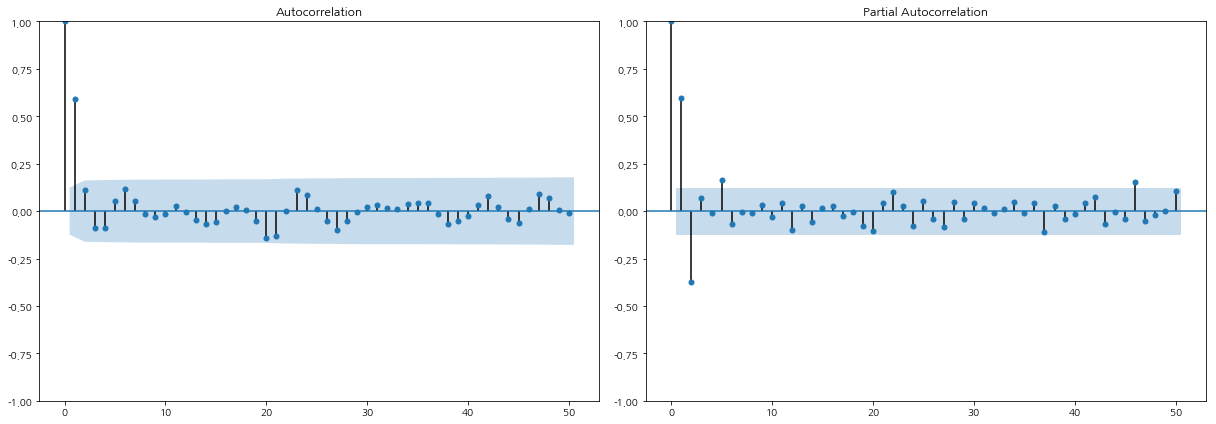

In [250]:
fig, ax = plt.subplots(1, 2, figsize=(17, 6))

from statsmodels.graphics.tsaplots import acf, pacf, plot_acf, plot_pacf

plot_acf(dt7, lags=50, ax=ax[0])
plot_pacf(dt7, lags = 50, ax=ax[1])
plt.tight_layout()
plt.show()

- ACF: lag 1에서 절단양상이 보이며, 이후 시점에서는 신뢰구간 내 값이 위치(q=1)
- PACF: lag 2에서 절단양상이 보이며, 이후 시점에서는 대체로 신뢰구간 내 값 위치(p=2)

**따라서, ARMA(2, 1) 모형을 구축**

In [263]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(dt7.values, order=(2, 0, 1)) #p, d, q, 일차원으로 넘겨야 plot이 나옴
rs = model.fit()

print(rs.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  250
Model:                 ARIMA(2, 0, 1)   Log Likelihood                -345.443
Date:                Mon, 28 Jul 2025   AIC                            700.887
Time:                        15:48:32   BIC                            718.494
Sample:                             0   HQIC                           707.973
                                - 250                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0051      0.122     -0.042      0.966      -0.244       0.233
ar.L1          0.6199      0.172      3.613      0.000       0.284       0.956
ar.L2         -0.2538      0.120     -2.115      0.0

ARMA(2, 1) 모델 학습 결과이다. 

- Log Likelihood 값은 수치가 높을수록 모형 적합도가 높아짐 -345.443(낮음)
- AIC(낮을수록 좋음): 700.887
- BIC(낮을수록 좋음, 모델 단순성까지 고려): 718.494
- 모수추정결과: ma.L1를 제외한 모든 항목이 유의확률 5% 하에서 통계적으로 유의
    - ar.L1: 유의미한 AR(1) 계수
    - ar.L2: 유의미한 AR(2) 계수
    - ma.L1: MA(1) 계수 통계적으로 유의하지 않음
    - sigma2: 오차의 분산(낮을수록 예측이 정밀함)

- 잔차진단: 독립성, 등분산성 만족(정규성 불만족)
  - Ljung-Box: p-value 0.99 로 잔차에 자기상관 없음
  - Jarque-Bera (JB): p-value 0.01로 잔차가 정규분포를 따르지 않음
  - Heteroskedasticity (H): p-value 0.54로 잔차의 분산이 일정함

MAE: 1.028
RMSE: 1.295


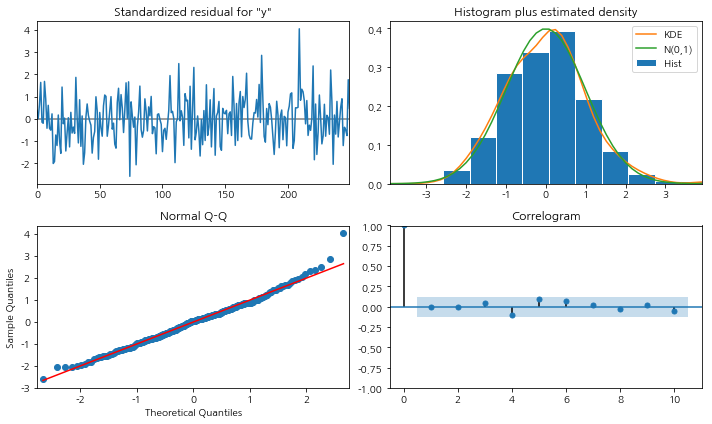

In [264]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import statsmodels.api as sm

forecast = rs.get_forecast(steps=len(dt7))
f_mean = forecast.predicted_mean
MAE = mean_absolute_error(dt7, f_mean)
rmse = np.sqrt(mean_squared_error(dt7, f_mean))
print(f"MAE: {MAE:.3f}")
print(f"RMSE: {rmse:.3f}")
rs.plot_diagnostics(figsize=(10, 6)) #잔차 그래프
plt.tight_layout()
plt.show()

모델의 성능을 mse, rmse로 출력하고, 잔차 검정결과를 plot으로 표시하였다.  
수치 상으로는 정규성을 만족하지 않는다고 표시되었으나, Q-Q plot 상에서는 상 하단의 outterlier로 판단되는 일부 point를 제외하고는  
정규성을 만족하는 것으로 판단된다.  

따라서, 정규성, 등분산성, 독립성을 모두 만족하는 것으로 판단한다. 

# 최적화

In [270]:
from pmdarima import auto_arima

model2 = auto_arima(dt7.values, seasonal=False, stepwise=True)
print(model2.summary())

model2 = ARIMA(dt7.values, order=(3, 0, 1)).fit() #p, d, q, 일차원으로 넘겨야 plot이 나옴

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  250
Model:               SARIMAX(3, 0, 1)   Log Likelihood                -343.103
Date:                Mon, 28 Jul 2025   AIC                            696.207
Time:                        16:01:59   BIC                            713.814
Sample:                             0   HQIC                           703.293
                                - 250                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0126      0.129     -0.098      0.922      -0.265       0.240
ar.L2          0.2665      0.124      2.149      0.032       0.023       0.510
ar.L3         -0.2442      0.092     -2.646      0.0

auto arima로 p, q계수를 자동으로 최적화하였으며, ARMA(3, 1)모델로 생성하였다.  

AIC, BIC 값이 이전 모델에 비해 696.207, 713.814로 줄어들었으며(더 좋아졌으며),   
여전히 Jarque-Bera 잔차 정규성 검정결과, 정규성을 만족하지 않는 것으로 확인되었다.   
ar.L1 계수가 통계적으로 유의하지 않다.  

MAE: 1.028
RMSE: 1.296


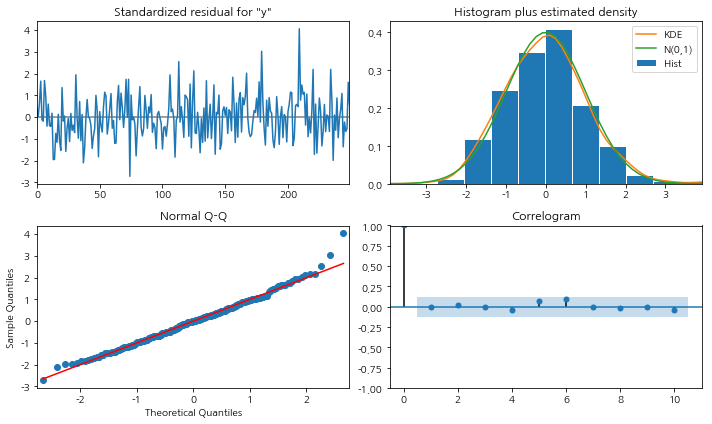

In [271]:
forecast = model2.get_forecast(steps=len(dt7))
f_mean = forecast.predicted_mean
MAE = mean_absolute_error(dt7, f_mean)
rmse = np.sqrt(mean_squared_error(dt7, f_mean))
print(f"MAE: {MAE:.3f}")
print(f"RMSE: {rmse:.3f}")
model2.plot_diagnostics(figsize=(10, 6)) #잔차 그래프
plt.tight_layout()
plt.show()